## Version 2

In [1]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Freemoves)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the **freemoves** dataset.
# ---
# **Version:** GEGE Freemoves (Adapted from Guided)
# ---

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager
import warnings # To suppress specific warnings if needed
import gc # For garbage collection

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing
try:
    set_config(enable_metadata_routing=True)
    print(f"Scikit-learn metadata routing enabled: {set_config(True)}")
except ValueError as e:
    print(f"Could not enable metadata routing (likely older scikit-learn): {e}")
    print("Proceeding without metadata routing.")


# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")


Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [ ]:
# %% [markdown]
# ## 1. Load Data (Freemoves)
#
# Load the freemoves dataset files.

# %%
# File paths for FREEMOVES dataset
X_TRAIN_VAL_PATH_FREE = "freemoves_dataset_X.npy"
Y_TRAIN_VAL_PATH_FREE = "freemoves_dataset_y.npy"
X_TEST_PATH_FREE = "freemoves_testset_X.npy" # Path to freemoves test data

# Load the training/validation data
try:
    X_train_val_raw_free = np.load(X_TRAIN_VAL_PATH_FREE)
    y_train_val_raw_free = np.load(Y_TRAIN_VAL_PATH_FREE)
    # Load the test data structure description
    X_test_raw_info_free = np.load(X_TEST_PATH_FREE, mmap_mode='r')
    print("Freemoves data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading freemoves data files: {e}")
    raise e

# Print shapes to verify
print("Raw Freemoves Training/Validation Data Shapes:")
print(f"X_train_val_raw_free: {X_train_val_raw_free.shape}")
print(f"y_train_val_raw_free: {y_train_val_raw_free.shape}")
print("\nRaw Freemoves Test Data Shape (for info):")
print(f"X_test_raw_info_free: {X_test_raw_info_free.shape}")

# Constants derived from freemoves data
N_SESSIONS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[0]
# Assuming N_ELECTRODES and N_JOINTS are the same as guided
N_ELECTRODES = X_train_val_raw_free.shape[1]
N_TIME_POINTS_TRAIN_VAL_FREE = X_train_val_raw_free.shape[2]
N_JOINTS = y_train_val_raw_free.shape[1]

print(f"\nNumber of Freemoves Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL_FREE}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session (Freemoves): {N_TIME_POINTS_TRAIN_VAL_FREE}")
print(f"Number of Joints: {N_JOINTS}")

Freemoves data loaded successfully.
Raw Freemoves Training/Validation Data Shapes:
X_train_val_raw_free: (5, 8, 270000)
y_train_val_raw_free: (5, 51, 270000)

Raw Freemoves Test Data Shape (for info):
X_test_raw_info_free: (5, 308, 8, 500)

Number of Freemoves Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session (Freemoves): 270000
Number of Joints: 51


In [3]:


# %% [markdown]
# ## 2. Signal Filtering (Freemoves)
#
# Applying DC offset removal, band-pass filtering, and Notch filtering.

# %%
# Filtering functions (same as before)
from scipy.signal import butter, filtfilt, iirnotch

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs; low = lowcut / nyq; high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut must be > 0.")
     if low >= high: raise ValueError("Lowcut must be < Highcut.")
     b, a = butter(order, [low, high], btype='band'); return b, a

def iir_notch(f0, Q, fs):
    b, a = iirnotch(f0, Q, fs); return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=5):
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     if data.shape[-1] <= bandpass_order * 3:
         print(f"Warning: Skipping bandpass (len {data.shape[-1]} <= {bandpass_order*3})")
         filtered_data = data
     else: filtered_data = filtfilt(b_band, a_band, data, axis=-1)
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)
     if filtered_data.shape[-1] <= 9: # Check length for notch
         print(f"Warning: Skipping notch (len {filtered_data.shape[-1]} <= 9)")
         return filtered_data
     else: return filtfilt(b_notch, a_notch, filtered_data, axis=-1)

FS = 1024; LOWCUT = 20; HIGHCUT = 450; NOTCH_FREQ = 50.0; NOTCH_Q = 30.0

with timer("Applying Signal Filtering (Freemoves)"):
    X_train_val_filtered_free = np.zeros_like(X_train_val_raw_free)
    for i in range(N_SESSIONS_TRAIN_VAL_FREE):
        session_data = X_train_val_raw_free[i]
        dc_removed = session_data - np.mean(session_data, axis=-1, keepdims=True)
        X_train_val_filtered_free[i] = apply_filters(dc_removed, LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS)
    X_train_val_to_window_free = X_train_val_filtered_free
    print(f"Applied filters to freemoves data.")


Applying Signal Filtering (Freemoves)...
Applied filters to freemoves data.
Applying Signal Filtering (Freemoves) done in 0.96 seconds.



In [5]:

# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Freemoves)
#
# Segment the filtered freemoves sEMG and raw joint angle data.

# %%
# Windowing Parameters (same as guided)
WINDOW_SIZE = 500
OVERLAP_PERCENTAGE = 0.50
step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
print(f"Window Size (k): {WINDOW_SIZE}, Overlap: {OVERLAP_PERCENTAGE*100:.0f}%, Step Size: {step}")

# Windowing function (same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    if n_timepoints < window_size:
        print(f"Warning: Session duration ({n_timepoints}) < window size ({window_size}). Cannot create windows.")
        return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    total_windows = 0
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]; session_y = y_raw[session_idx]
        if session_y.shape[-1] != n_timepoints:
             print(f"Warning: Timepoints mismatch X/y session {session_idx}. Skipping."); continue
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        num_session_windows = len(start_indices)
        if num_session_windows == 0: print(f"Warning: No windows for session {session_idx}."); continue
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            if end_idx > n_timepoints: continue
            X_windowed_list.append(session_X[:, start_idx:end_idx])
            y_windowed_list.append(session_y[:, end_idx - 1]) # Target is end of window
            groups_list.append(session_idx)
        print(f"Session {session_idx}: Created {num_session_windows} windows.")
        total_windows += num_session_windows
    if total_windows == 0: print("Error: No windows created."); return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)
    try:
        X_windowed_np = np.stack(X_windowed_list); y_windowed_np = np.stack(y_windowed_list); groups_np = np.array(groups_list)
    except Exception as e: print(f"Error during stacking: {e}"); raise e
    return X_windowed_np, y_windowed_np, groups_np

# Create the windowed freemoves dataset
with timer("Creating overlapping windows (Freemoves)"):
    X_windowed_free, y_windowed_free, groups_free = create_overlapping_windows(
        X_train_val_to_window_free, y_train_val_raw_free, WINDOW_SIZE, step
    )

if X_windowed_free.size == 0:
    print("Window creation failed. Exiting.")
    # Handle error appropriately
else:
    print("\nFreemoves Windowed Data Shapes:")
    print(f"X_windowed_free: {X_windowed_free.shape}")
    print(f"y_windowed_free: {y_windowed_free.shape}") # Should have 51 columns
    print(f"groups_free: {groups_free.shape}")
    print(f"Unique groups (sessions): {np.unique(groups_free)}")
    assert y_windowed_free.shape[1] == N_JOINTS, "Incorrect number of target joints!"


Window Size (k): 500, Overlap: 50%, Step Size: 250
Creating overlapping windows (Freemoves)...
Session 0: Created 1079 windows.
Session 1: Created 1079 windows.
Session 2: Created 1079 windows.
Session 3: Created 1079 windows.
Session 4: Created 1079 windows.
Creating overlapping windows (Freemoves) done in 4.15 seconds.


Freemoves Windowed Data Shapes:
X_windowed_free: (5395, 8, 500)
y_windowed_free: (5395, 51)
groups_free: (5395,)
Unique groups (sessions): [0 1 2 3 4]


In [6]:

# %% [markdown]
# ## 4. Data Preprocessing (Features - Freemoves)
#
# `StandardScaler` will be applied within pipelines / CV loops.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.")

Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.


In [7]:


# %% [markdown]
# ## 5. Custom Feature Extractor (Freemoves - Use Corrected Version)
#
# Use the same corrected `EMGFeatureExtractor` class definition.

# %%
# Corrected EMGFeatureExtractor Class Definition (Copied from previous corrected version)
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        self.zc_threshold = zc_threshold; self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features; self.verbose = verbose
    def _get_features_to_extract(self):
        if self.selected_features is None: return self.ALL_AVAILABLE_FEATURES
        else:
            current_selection = list(self.selected_features)
            invalid_features = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid_features: raise ValueError(f"Invalid features: {invalid_features}")
            features_to_use = set(current_selection)
            missing_required = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing_required:
                if self.verbose: print(f"Note: Adding missing required: {missing_required}")
                features_to_use.update(missing_required)
            return sorted(list(features_to_use))
    def fit(self, X, y=None):
        self._features_to_extract = self._get_features_to_extract()
        if self.verbose: print(f"Extractor fit. Features: {self._features_to_extract}")
        return self
    def transform(self, X):
        if not hasattr(self, '_features_to_extract'): self.fit(X)
        features_to_extract = self._features_to_extract; n_selected = len(features_to_extract)
        if n_selected == 0: return np.empty((X.shape[0], 0))
        if X.ndim != 3: raise ValueError(f"Input X must be 3D, got {X.ndim}D")
        n_windows, n_electrodes, window_size = X.shape
        features = np.zeros((n_windows, n_electrodes * n_selected))
        if self.verbose: print(f"Extracting {n_selected} features from {n_windows} windows...")
        for i in range(n_windows):
            window_features = []; stats = {} # Define stats inside window loop
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                # Optimized stats calculation
                stats.clear() # Clear stats for new channel
                calc_abs = any(f in features_to_extract for f in ['MAV', 'MPR'])
                calc_var = any(f in features_to_extract for f in ['Var', 'STD', 'MPR'])
                calc_std = any(f in features_to_extract for f in ['STD', 'MPR'])
                if calc_abs: stats['abs_data'] = np.abs(channel_data)
                if calc_var: stats['var'] = np.var(channel_data)
                if calc_std: stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0
                if 'MAV' in features_to_extract: stats['mav'] = np.mean(stats['abs_data']) if calc_abs else np.mean(np.abs(channel_data))

                for feature_name in features_to_extract:
                    if feature_name == 'MAV': window_features.append(stats['mav'])
                    elif feature_name == 'RMS': window_features.append(np.sqrt(np.mean(channel_data**2)))
                    elif feature_name == 'Var': window_features.append(stats['var'])
                    elif feature_name == 'STD': window_features.append(stats['std'])
                    elif feature_name == 'ZC': window_features.append(np.sum(np.diff(np.signbit(channel_data - self.zc_threshold))))
                    elif feature_name == 'MPR':
                        threshold_mpr = stats['std'] if stats['std'] > 1e-9 else 1e-9
                        window_features.append(np.mean(stats['abs_data'] > threshold_mpr) if calc_abs else np.mean(np.abs(channel_data)>threshold_mpr))
                    elif feature_name == 'WL': window_features.append(np.sum(np.abs(np.diff(channel_data))))
                    elif feature_name == 'SSC':
                         diff_sig = np.diff(channel_data); sign_change = (diff_sig[:-1] * diff_sig[1:]) < 0
                         magnitude_check = (np.abs(diff_sig[:-1]) > self.ssc_threshold) | (np.abs(diff_sig[1:]) > self.ssc_threshold)
                         window_features.append(np.sum(sign_change & magnitude_check))
            if len(window_features) != n_electrodes * n_selected: print(f"Warning: Feature count mismatch win {i}"); features[i, :] = np.nan
            else: features[i, :] = window_features
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        if self.verbose: print("Extraction complete.")
        return features
    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, '_features_to_extract'): features_to_extract = self._get_features_to_extract()
        else: features_to_extract = self._features_to_extract
        feature_names = []
        try: global N_ELECTRODES; num_electrodes = N_ELECTRODES
        except NameError: num_electrodes = 8
        for j in range(num_electrodes):
            for feature_name in features_to_extract: feature_names.append(f"Elec{j+1}_{feature_name}")
        return np.array(feature_names)


# Extract all features for the freemoves dataset
with timer("Extracting Features (Freemoves - All Features)"):
     if 'X_windowed_free' not in locals() or X_windowed_free.size == 0:
          raise RuntimeError("X_windowed_free is not defined or empty.")
     feature_extractor_all_free = EMGFeatureExtractor(verbose=False)
     feature_extractor_all_free.fit(X_windowed_free) # Fit first
     X_features_free = feature_extractor_all_free.transform(X_windowed_free) # Then transform

print("Freemoves Feature Matrix Shape (All Features):")
print(f"X_features_free: {X_features_free.shape}")
n_expected_features_all_free = N_ELECTRODES * len(feature_extractor_all_free._features_to_extract)
print(f"Expected number of features: {n_expected_features_all_free}")
assert X_features_free.shape[1] == n_expected_features_all_free, "Dimension mismatch!"
feature_names_free = feature_extractor_all_free.get_feature_names_out()
print(f"\nGenerated {len(feature_names_free)} feature names. Examples: {feature_names_free[:5]}")


Extracting Features (Freemoves - All Features)...
Extracting Features (Freemoves - All Features) done in 5.44 seconds.

Freemoves Feature Matrix Shape (All Features):
X_features_free: (5395, 64)
Expected number of features: 64

Generated 64 feature names. Examples: ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']


Using GroupKFold with 5 splits for Freemoves.


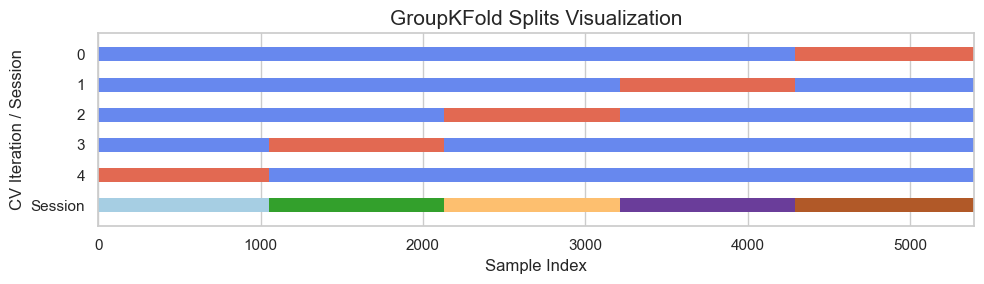

In [10]:

# %% [markdown]
# ## 6. Cross-Validation Strategy (Freemoves)
#
# Using `GroupKFold` with session IDs.

# %%
N_SPLITS_FREE = N_SESSIONS_TRAIN_VAL_FREE # Should be 5
cv_strategy_free = GroupKFold(n_splits=N_SPLITS_FREE)
print(f"Using GroupKFold with {N_SPLITS_FREE} splits for Freemoves.")

# Plotting function (same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    # Generate splits and plot
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        # Plotting the splits for each CV iteration
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    # Plotting the session groups
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    # Formatting the plot
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()
    
# Plot for freemoves setup
if 'X_features_free' in locals() and X_features_free.size > 0:
    plot_cv_indices(cv_strategy_free, X_features_free, y_windowed_free, groups_free, N_SPLITS_FREE)
else:
    print("Skipping CV plot: Freemoves features not available.")


In [11]:

# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Freemoves - All Features)
#
# Evaluate Ridge, Lasso, RF using all features on the freemoves data. **Using correct 51-dim target.**

# %%
# Performance Metrics & Scorers (same definitions)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))

def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0, keepdims=True)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    if denominator < 1e-9: return 0.0 if numerator < 1e-9 else np.inf
    else: return numerator / denominator

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
print("Scorers defined: RMSE (neg), NMSE (neg), R2.")
# Select Baseline Models (same models, new instances via clone later)
model_ridge_base = Ridge(alpha=1.0)
model_lasso_base = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42)
model_rf_base = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
baseline_models_to_evaluate_free = {"Ridge": model_ridge_base, "Lasso": model_lasso_base, "RandomForest": model_rf_base}

# Store freemoves results
all_cv_results_free = {}
results_summary_list_free = []

# %%
# Evaluate baseline models on FREEMOVES data with ALL features
print("--- Evaluating Baseline Models (Freemoves - ALL Features) ---")
cv_params_free = {'groups': groups_free}

for model_name, model in baseline_models_to_evaluate_free.items():
    with timer(f"Cross-validating {model_name} (freemoves, all features)"):
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # All features
            ('scaling', StandardScaler()),
            ('regression', clone(model)) # Clone model for safety
        ])
        # Perform cross-validation using freemoves data and CORRECT target
        try:
             scores = cross_validate(
                 pipeline, X_windowed_free, y_windowed_free, # Use freemoves data
                 cv=cv_strategy_free, scoring=scorers, n_jobs=-1,
                 return_train_score=False, params=cv_params_free, error_score='raise'
             )
        except TypeError as e:
             # Fallback loop (same logic, just using _free variables)
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, using manual loop...")
                fold_scores = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time()
                    pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                    end_fit_time = time.time()
                    y_pred = pipeline.predict(X_windowed_free[test_idx])
                    end_score_time = time.time()
                    fold_scores['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        score_value = scorer_func(pipeline, X_windowed_free[test_idx], y_windowed_free[test_idx])
                        fold_scores[score_name].append(score_value)
                scores = {f"test_{key}": np.array(values) for key, values in fold_scores.items() if key in scorers}
                scores['fit_time'] = np.array(fold_scores['fit_time'])
                scores['score_time'] = np.array(fold_scores['score_time'])
            else: raise e
        all_cv_results_free[model_name] = scores

# %%
# Display Freemoves Baseline CV Results (All Features)
print("\nFreemoves Baseline CV Performance Results (All Features):")
for model_name, scores in all_cv_results_free.items():
     if model_name in baseline_models_to_evaluate_free:
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
        fit_time_mean = np.nanmean(scores['fit_time']); score_time_mean = np.nanmean(scores['score_time'])
        print(f"\n--- {model_name} (Freemoves - All Features) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}") # Check if R2 makes sense now
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s"); print(f"  Avg Score Time: {score_time_mean:.2f}s")
        results_summary_list_free.append({'Model': model_name, 'Type': 'Baseline_AllFeat_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Baseline Summary Table (All Features) ---")
if not results_df_free.empty: print(results_df_free[results_df_free['Type'] == 'Baseline_AllFeat_Free'].to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

Scorers defined: RMSE (neg), NMSE (neg), R2.
--- Evaluating Baseline Models (Freemoves - ALL Features) ---
Cross-validating Ridge (freemoves, all features)...
Cross-validating Ridge (freemoves, all features) done in 26.05 seconds.

Cross-validating Lasso (freemoves, all features)...
Cross-validating Lasso (freemoves, all features) done in 32.54 seconds.

Cross-validating RandomForest (freemoves, all features)...
Cross-validating RandomForest (freemoves, all features) done in 38.76 seconds.


Freemoves Baseline CV Performance Results (All Features):

--- Ridge (Freemoves - All Features) ---
  RMSE: 10.9835 +/- 1.3112
  NMSE: 0.8587 +/- 0.1480
  R2 Score: -0.0047 +/- 0.1439
  Avg Fit Time: 12.08s
  Avg Score Time: 2.12s

--- Lasso (Freemoves - All Features) ---
  RMSE: 10.9395 +/- 1.2890
  NMSE: 0.8511 +/- 0.1394
  R2 Score: 0.0007 +/- 0.1239
  Avg Fit Time: 25.51s
  Avg Score Time: 2.26s

--- RandomForest (Freemoves - All Features) ---
  RMSE: 10.6944 +/- 1.8233
  NMSE: 0.8072 +/- 0.162


--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---
Extracting & Scaling Freemoves features for Full Importance Analysis...
Extracting & Scaling Freemoves features for Full Importance Analysis done in 6.40 seconds.

Training RF on full freemoves scaled data for Importance Plot...
Training RF on full freemoves scaled data for Importance Plot done in 7.00 seconds.


Freemoves RF Feature Importances (Top 30 - full data):


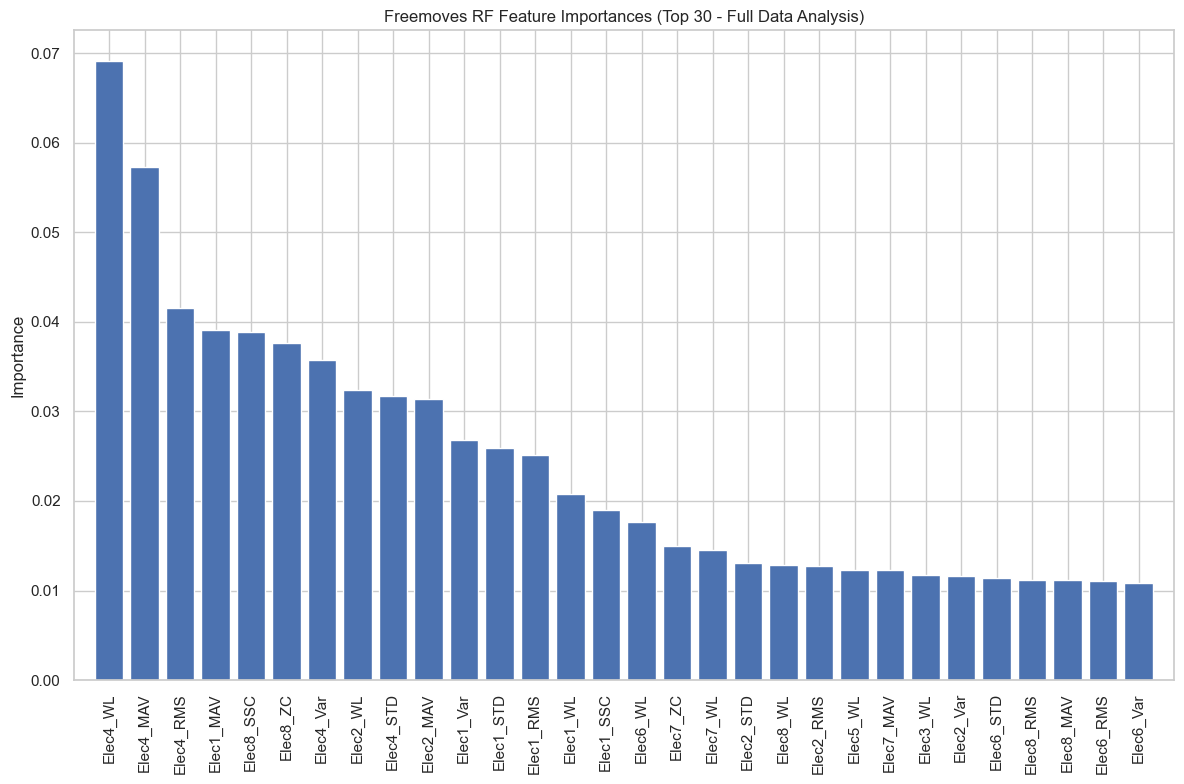


--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---

--- Processing Freemoves Fold 1/5 ---
  Fold 1: Feature Extraction...
  Fold 1: Feature Extraction done in 6.73 seconds.

  Fold 1: Scaling...
  Fold 1: Scaling done in 0.01 seconds.

  Fold 1: RFECV (estimator=Ridge, n_jobs=1)...
    RFECV selected 49 features.
  Fold 1: RFECV (estimator=Ridge, n_jobs=1) done in 0.59 seconds.

  Fold 1: Importance Selection (estimator=RF)...
    Importance selected top 32 features.
  Fold 1: Importance Selection (estimator=RF) done in 2.31 seconds.

  Fold 1: Evaluating Ridge_RFECV...
    Ridge_RFECV - RMSE: 9.4018, NMSE: 0.7944, R2: -0.0468
  Fold 1: Evaluating Ridge_RFECV done in 0.02 seconds.

  Fold 1: Evaluating RF_Importance...
    RF_Importance - RMSE: 9.2646, NMSE: 0.7714, R2: -0.0189
  Fold 1: Evaluating RF_Importance done in 3.09 seconds.

  Fold 1: Evaluating Ridge_Importance...
    Ridge_Importance - RMSE: 9.8108, NMSE: 0.8650, R2: -0.1041
  Fold 1: Evalu

In [12]:
# %% [markdown]
# ## 8. Feature Importance Analysis and Integrated Selection (Freemoves)
#
# Perform analysis and integrated selection for the freemoves dataset. Expect longer runtimes.

# %%
# --- Feature Importance Analysis (Freemoves Data - for Insight) ---
print("\n--- RF Feature Importance Analysis (Freemoves Full Data - Insight) ---")
analysis_pipeline_full_free = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler())])
with timer("Extracting & Scaling Freemoves features for Full Importance Analysis"):
    X_features_scaled_full_free = analysis_pipeline_full_free.fit_transform(X_windowed_free, y_windowed_free)
    feature_names_full_free = analysis_pipeline_full_free.named_steps['feature_extraction'].get_feature_names_out()
with timer("Training RF on full freemoves scaled data for Importance Plot"):
    model_rf_analysis_free = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
    model_rf_analysis_free.fit(X_features_scaled_full_free, y_windowed_free)
importances_full_free = model_rf_analysis_free.feature_importances_
indices_full_free = np.argsort(importances_full_free)[::-1]
print("\nFreemoves RF Feature Importances (Top 30 - full data):")
n_top_features_plot = 30
plt.figure(figsize=(12, 8)); plt.title("Freemoves RF Feature Importances (Top 30 - Full Data Analysis)")
top_indices_free = indices_full_free[:n_top_features_plot]
plt.bar(range(len(top_indices_free)), importances_full_free[top_indices_free], align='center')
plt.xticks(range(len(top_indices_free)), [feature_names_full_free[i] for i in top_indices_free], rotation=90)
plt.xlim([-1, len(top_indices_free)]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()
del X_features_scaled_full_free # Clear memory
gc.collect()


# %% [markdown]
# ### 8.1 Cross-Validation with Integrated Feature Selection (Freemoves - Expanded)

# %%
print("\n--- Evaluating Models with Integrated Feature Selection (Freemoves - Nested CV) ---")
# Settings (same as guided)
MIN_FEATURES_RFECV = 10; STEP_RFECV = 5; CV_INNER_RFECV = 3; N_FEATURES_IMPORTANCE = 32

fs_results_free = {"Ridge_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "Ridge_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}, "RF_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []}}
model_ridge_final_free = Ridge(alpha=1.0)
model_rf_final_free = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
model_ridge_for_rfecv_free = Ridge(alpha=1.0)
model_rf_for_importance_free = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)

fold_num = 0
feature_extractor_cv_free = EMGFeatureExtractor() # New instance

# Outer CV Loop (LOSO) for Freemoves
for train_idx, test_idx in cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\n--- Processing Freemoves Fold {fold_num}/{N_SPLITS_FREE} ---")
    start_fold_time = time.time()
    # 1. Split raw windowed data
    X_train_fold_raw, X_test_fold_raw = X_windowed_free[train_idx], X_windowed_free[test_idx]
    y_train_fold, y_test_fold = y_windowed_free[train_idx], y_windowed_free[test_idx]
    # 2. Extract features
    with timer(f"  Fold {fold_num}: Feature Extraction"):
        X_train_features = feature_extractor_cv_free.transform(X_train_fold_raw)
        X_test_features = feature_extractor_cv_free.transform(X_test_fold_raw)
        if fold_num == 1: feature_names_free = feature_extractor_cv_free.get_feature_names_out()
    # 3. Scale features
    with timer(f"  Fold {fold_num}: Scaling"):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_test_scaled = scaler.transform(X_test_features)
    # --- Feature Selection Step ---
    selected_indices_rfecv = None; n_features_rfecv = X_train_scaled.shape[1]
    selected_indices_importance = None; n_features_importance = X_train_scaled.shape[1]
    # 4a. RFECV (n_jobs=1) - **EXPECT THIS TO BE SLOW**
    with timer(f"  Fold {fold_num}: RFECV (estimator=Ridge, n_jobs=1)"):
        try:
            rfecv_selector = RFECV(estimator=clone(model_ridge_for_rfecv_free), step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'], min_features_to_select=MIN_FEATURES_RFECV, n_jobs=1)
            rfecv_selector.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            selected_indices_rfecv = rfecv_selector.support_; n_features_rfecv = rfecv_selector.n_features_
            print(f"    RFECV selected {n_features_rfecv} features.")
        except Exception as e: print(f"    RFECV failed: {e}. Using all."); selected_indices_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)
    # 4b. Importance Thresholding
    with timer(f"  Fold {fold_num}: Importance Selection (estimator=RF)"):
        try:
            rf_importance_model = clone(model_rf_for_importance_free)
            rf_importance_model.fit(X_train_scaled, y_train_fold) # Fit requires correct target shape
            importances = rf_importance_model.feature_importances_
            indices_sorted = np.argsort(importances)[::-1]
            selected_indices_importance = np.zeros(X_train_scaled.shape[1], dtype=bool)
            n_select = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            selected_indices_importance[indices_sorted[:n_select]] = True; n_features_importance = n_select
            print(f"    Importance selected top {n_features_importance} features.")
        except Exception as e: print(f"    Importance failed: {e}. Using all."); selected_indices_importance = np.ones(X_train_scaled.shape[1], dtype=bool)
    # --- Model Evaluation Step ---
    def evaluate_model_free(model_key, model_instance, X_train, y_train, X_test, y_test, selected_indices, n_features):
        results_dict = fs_results_free # Use the freemoves results dict
        if selected_indices is None or not np.any(selected_indices): print(f"    Skipping {model_key}"); results_dict[model_key]['test_rmse'].append(np.nan); results_dict[model_key]['test_nmse'].append(np.nan); results_dict[model_key]['test_r2'].append(np.nan); results_dict[model_key]['n_features'].append(X_train.shape[1]); return
        X_train_sel = X_train[:, selected_indices]; X_test_sel = X_test[:, selected_indices]
        model_instance = clone(model_instance)
        model_instance.fit(X_train_sel, y_train) # Fit requires correct target shape
        y_pred = model_instance.predict(X_test_sel)
        rmse = root_mean_squared_error(y_test, y_pred); nmse = normalized_mean_squared_error(y_test, y_pred); r2 = r2_score(y_test, y_pred)
        results_dict[model_key]['test_rmse'].append(-rmse); results_dict[model_key]['test_nmse'].append(-nmse); results_dict[model_key]['test_r2'].append(r2); results_dict[model_key]['n_features'].append(n_features)
        print(f"    {model_key} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}, R2: {r2:.4f}")

    fold_eval_start_time = time.time()
    with timer(f"  Fold {fold_num}: Evaluating Ridge_RFECV"): evaluate_model_free("Ridge_RFECV", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    with timer(f"  Fold {fold_num}: Evaluating RF_Importance"): evaluate_model_free("RF_Importance", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating Ridge_Importance"): evaluate_model_free("Ridge_Importance", model_ridge_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)
    with timer(f"  Fold {fold_num}: Evaluating RF_RFECV"): evaluate_model_free("RF_RFECV", model_rf_final_free, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)
    # Record Timings
    fold_end_time = time.time(); total_fold_time = fold_end_time - start_fold_time
    for key in fs_results_free: fs_results_free[key]['fit_time'].append(total_fold_time); fs_results_free[key]['score_time'].append(0)
    # Clean up memory
    del X_train_fold_raw, X_test_fold_raw, y_train_fold, y_test_fold, X_train_features, X_test_features, X_train_scaled, X_test_scaled
    gc.collect()

# %%
# Aggregate and Display Freemoves FS Results
print("\n--- Freemoves Performance Results (Integrated Feature Selection - Expanded) ---")
results_summary_list_free = [item for item in results_summary_list_free if item['Type'] != 'Baseline_FS_Free'] # Clear previous FS results for freemoves
for model_fs_name, scores in fs_results_free.items():
    if not scores['test_rmse']: print(f"Warning: No scores for {model_fs_name}."); continue
    mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
    fit_time_mean = np.nanmean(scores['fit_time']); avg_n_features = np.nanmean(scores['n_features']); std_n_features = np.nanstd(scores['n_features'])
    print(f"\n--- {model_fs_name} (Freemoves) ---")
    print(f"  Avg. Features Selected: {avg_n_features:.1f} +/- {std_n_features:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}"); print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Total Time per Fold: {fit_time_mean:.2f}s")
    results_summary_list_free.append({'Model': model_fs_name, 'Type': 'Baseline_FS_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

results_df_free = pd.DataFrame(results_summary_list_free)
print("\n--- Freemoves Updated Summary Table (Including Integrated FS) ---")
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Results DataFrame is empty.")

In [13]:


# %% [markdown]
# ## 9. Sophisticated Approach: Neural Network (Freemoves)
#
# Evaluate the MLP on the freemoves dataset.

# %%
# NN Architecture & Training Functions (same definitions)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1) # Added BatchNorm
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2) # Added BatchNorm
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x))))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN (Copied from original GEGE)

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Zero gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item() * inputs.size(0) # Accumulate loss

    return running_loss / len(dataloader.dataset) # Return average loss for the epoch

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad(): # Disable gradient calculations
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, targets) # Calculate loss
            running_loss += loss.item() * inputs.size(0) # Accumulate loss
            all_preds.append(outputs.cpu().numpy()) # Collect predictions (move back to CPU)
            all_targets.append(targets.cpu().numpy()) # Collect targets

    avg_loss = running_loss / len(dataloader.dataset)
    # Concatenate predictions and targets from all batches
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network (Freemoves)
# Hyperparameters (start with same as guided, might need tuning)
N_EPOCHS_FREE = 75; BATCH_SIZE_FREE = 64; LEARNING_RATE_FREE = 0.001; WEIGHT_DECAY_FREE = 1e-5

# Ensure X_features_free exists
if 'X_features_free' not in locals(): raise RuntimeError("X_features_free not available.")
X_input_for_nn_cv_free = X_features_free
n_input_features_free = X_input_for_nn_cv_free.shape[1]

nn_cv_scores_free = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print(f"\n--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: {n_input_features_free}) ---")

fold_num = 0
for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
    fold_num += 1
    print(f"\nStarting Freemoves NN CV Fold {fold_num}/{N_SPLITS_FREE}")
    start_fold_time = time.time()
    # 1. Split data
    X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]
    y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
    # 2. Scale features
    scaler_nn_fold = StandardScaler(); X_train_fold_scaled = scaler_nn_fold.fit_transform(X_train_fold); X_val_fold_scaled = scaler_nn_fold.transform(X_val_fold)
    # 3. Datasets & DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_FREE, shuffle=True, num_workers=2, pin_memory=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_FREE*2, shuffle=False, num_workers=2, pin_memory=True)
    # 4. Initialize model, loss, optimizer
    model_nn = EMG_NN(n_features=n_input_features_free, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=False) # Less verbose scheduler
    # 5. Training loop
    best_val_loss = float('inf'); epochs_no_improve = 0; patience = 15
    print(f"Fold {fold_num}: Training for up to {N_EPOCHS_FREE} epochs...")
    for epoch in range(N_EPOCHS_FREE):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
        if (epoch + 1) % 25 == 0 or epoch == N_EPOCHS_FREE - 1: print(f'  Epoch {epoch+1}/{N_EPOCHS_FREE}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')
        scheduler.step(val_loss_epoch)
        if val_loss_epoch < best_val_loss: best_val_loss = val_loss_epoch; epochs_no_improve = 0
        else: epochs_no_improve += 1
        if epochs_no_improve >= patience: print(f"  Early stopping @ epoch {epoch + 1}"); break
    fit_end_time = time.time()
    # 6. Evaluate
    print(f"Fold {fold_num}: Evaluating..."); _, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device); score_end_time = time.time()
    # 7. Calculate metrics
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold); nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold); r2_fold = r2_score(y_true_fold, y_pred_fold)
    nn_cv_scores_free['test_rmse'].append(-rmse_fold); nn_cv_scores_free['test_nmse'].append(-nmse_fold); nn_cv_scores_free['test_r2'].append(r2_fold)
    nn_cv_scores_free['fit_time'].append(fit_end_time - start_fold_time); nn_cv_scores_free['score_time'].append(score_end_time - fit_end_time)
    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")
    del model_nn, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Store overall NN results for freemoves
all_cv_results_free["NeuralNetwork_Free"] = nn_cv_scores_free

# %%
# Add Freemoves NN results to summary DataFrame
nn_model_name_free = "NeuralNetwork_Free"
if nn_model_name_free in all_cv_results_free:
    nn_scores = all_cv_results_free[nn_model_name_free]
    mean_rmse = -np.nanmean(nn_scores['test_rmse']); std_rmse = np.nanstd(nn_scores['test_rmse'])
    mean_nmse = -np.nanmean(nn_scores['test_nmse']); std_nmse = np.nanstd(nn_scores['test_nmse'])
    mean_r2 = np.nanmean(nn_scores['test_r2']); std_r2 = np.nanstd(nn_scores['test_r2'])
    fit_time_mean = np.nanmean(nn_scores['fit_time'])
    results_summary_list_free.append({'Model': nn_model_name_free, 'Type': 'Sophisticated_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})
    results_df_free = pd.DataFrame(results_summary_list_free)
    print("\n--- Freemoves Combined Model Comparison Table (incl. NN) ---")
    print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Neural Network results not found.")


--- Evaluating Neural Network (Freemoves - Manual CV, Input Features: 64) ---

Starting Freemoves NN CV Fold 1/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1: Training for up to 75 epochs...
  Epoch 25/75, Train Loss: 88.195617, Val Loss: 82.521848
  Epoch 50/75, Train Loss: 82.336576, Val Loss: 78.476609
  Epoch 75/75, Train Loss: 76.208079, Val Loss: 79.987061
Fold 1: Evaluating...
Fold 1 Metrics: RMSE=8.9435, NMSE=0.7188, R2=-5841715.5000

Starting Freemoves NN CV Fold 2/5
Fold 2: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 84.324692, Val Loss: 82.542723
  Epoch 50/75, Train Loss: 77.104227, Val Loss: 76.751844
  Epoch 75/75, Train Loss: 72.921364, Val Loss: 74.302330
Fold 2: Evaluating...
Fold 2 Metrics: RMSE=8.6199, NMSE=0.6337, R2=-4801856.5000

Starting Freemoves NN CV Fold 3/5
Fold 3: Training for up to 75 epochs...


...

  Epoch 25/75, Train Loss: 82.215769, Val Loss: 101.401272
  Epoch 50/75, Train Loss: 72.428847, Val Loss: 100.459002
  Epoch 75/75, Train Loss: 70.497658, Val Loss: 98.924193
Fold 3: Evaluating...
Fold 3 Metrics: RMSE=9.9461, NMSE=0.5696, R2=-7508959.5000

Starting Freemoves NN CV Fold 4/5
Fold 4: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 77.816687, Val Loss: 145.463465
  Early stopping @ epoch 40
Fold 4: Evaluating...
Fold 4 Metrics: RMSE=12.4337, NMSE=0.8447, R2=-11801565.0000

Starting Freemoves NN CV Fold 5/5
Fold 5: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 25/75, Train Loss: 83.621676, Val Loss: 109.400807
  Early stopping @ epoch 39
Fold 5: Evaluating...
Fold 5 Metrics: RMSE=10.7266, NMSE=0.8657, R2=-11335616.0000

--- Freemoves Combined Model Comparison Table (incl. NN) ---
             Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std       R2_mean       R2_std  FitTime
NeuralNetwork_Free    Sophisticated_Free    10.1340    1.3700     0.7265    0.1155 -8257942.5000 2841583.8360 678.6236
      RandomForest Baseline_AllFeat_Free    10.6944    1.8233     0.8072    0.1629        0.0514       0.1763  34.3753
          RF_RFECV      Baseline_FS_Free    10.7437    1.8775     0.8150    0.1717        0.0470       0.1813  16.9511
     RF_Importance      Baseline_FS_Free    10.8295    1.9017     0.8289    0.1788        0.0372       0.1832  16.9511
             Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511    0.1394        0.0007       0.1239  25.5090
       Ridge_RFECV      Baseline_FS_Free    10.9493   

In [14]:


# %% [markdown]
# ## 10. Objective 6: Ensembling Strategies (Freemoves)
#
# Implement Averaging and Stacking for the freemoves dataset.

# %% [markdown]
# ### 10.1 Generate Out-of-Fold (OOF) Predictions (Freemoves)

# %%
oof_predictions_free = {} # Dictionary for freemoves OOF predictions

# --- OOF for Baselines (All Features) ---
print("--- Generating OOF Predictions (Freemoves - Baselines All Features) ---")
baseline_pipelines_oof_free = {}
for model_name, model in baseline_models_to_evaluate_free.items(): # Use freemoves models
     baseline_pipelines_oof_free[model_name] = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
for model_name, pipeline in baseline_pipelines_oof_free.items():
     with timer(f"Generating OOF predictions for {model_name} (Freemoves)"):
         try: # Use freemoves data
              oof_preds = cross_val_predict(pipeline, X_windowed_free, y_windowed_free, cv=cv_strategy_free, n_jobs=-1, method='predict', params={'groups': groups_free})
         except TypeError as e: # Fallback
             if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                  print("Metadata routing failed, using manual loop...")
                  oof_preds_list = [None] * len(X_windowed_free)
                  for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_windowed_free, y_windowed_free, groups=groups_free)):
                      pipeline.fit(X_windowed_free[train_idx], y_windowed_free[train_idx])
                      fold_preds = pipeline.predict(X_windowed_free[test_idx])
                      for i, idx in enumerate(test_idx): oof_preds_list[idx] = fold_preds[i]
                  oof_preds = np.stack(oof_preds_list)
             else: raise e
         oof_predictions_free[model_name] = oof_preds
     print(f"Shape of {model_name} Freemoves OOF predictions: {oof_preds.shape}")

# --- OOF for Neural Network (Freemoves) ---
print("\n--- Generating OOF Predictions (Freemoves - Neural Network) ---")
N_EPOCHS_OOF_FREE = 75; BATCH_SIZE_OOF_FREE = 64; LEARNING_RATE_OOF_FREE = 0.001; WEIGHT_DECAY_OOF_FREE = 1e-5
nn_oof_preds_list_free = [None] * len(X_input_for_nn_cv_free)
if 'X_input_for_nn_cv_free' not in locals(): raise ValueError("NN features (freemoves) not found.")
n_input_features_oof_free = X_input_for_nn_cv_free.shape[1]
fold_num = 0
with timer("Generating OOF predictions for NN (Freemoves - Manual CV)"):
    for train_idx, val_idx in cv_strategy_free.split(X_input_for_nn_cv_free, y_windowed_free, groups=groups_free):
        fold_num += 1; print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS_FREE}") # Print progress
        # 1. Split data
        X_train_fold, X_val_fold = X_input_for_nn_cv_free[train_idx], X_input_for_nn_cv_free[val_idx]; y_train_fold, y_val_fold = y_windowed_free[train_idx], y_windowed_free[val_idx]
        # 2. Scale features
        scaler_oof = StandardScaler(); X_train_fold_scaled = scaler_oof.fit_transform(X_train_fold); X_val_fold_scaled = scaler_oof.transform(X_val_fold)
        # 3. Datasets & DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold)); val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_OOF_FREE, shuffle=True); val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_OOF_FREE*2, shuffle=False)
        # 4. Initialize model, loss, optimizer
        model_nn_oof = EMG_NN(n_features=n_input_features_oof_free, n_joints=N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(model_nn_oof.parameters(), lr=LEARNING_RATE_OOF_FREE, weight_decay=WEIGHT_DECAY_OOF_FREE)
        # 5. Training loop
        for epoch in range(N_EPOCHS_OOF_FREE): _ = train_nn_epoch(model_nn_oof, train_loader, criterion, optimizer, device)
        # 6. Evaluate & GET PREDICTIONS
        _, y_pred_fold, _ = evaluate_nn_model(model_nn_oof, val_loader, criterion, device)
        # 7. Store predictions
        for i, idx in enumerate(val_idx):
             if idx < len(nn_oof_preds_list_free): nn_oof_preds_list_free[idx] = y_pred_fold[i]
             else: print(f"Warning: Index {idx} out of bounds for list size {len(nn_oof_preds_list_free)}")
        # Clean up
        del model_nn_oof, train_loader, val_loader, train_dataset, val_dataset; gc.collect(); torch.cuda.empty_cache()

# Combine NN OOF predictions
contains_none = any(pred is None for pred in nn_oof_preds_list_free)
if contains_none:
    print("Warning: Filling missing NN OOF preds (Freemoves) with zeros.")
    shapes = [p.shape for p in nn_oof_preds_list_free if p is not None]; avg_shape = shapes[0] if shapes else (N_JOINTS,)
    fill_value = np.zeros(avg_shape); nn_oof_preds_filled = [p if p is not None else fill_value for p in nn_oof_preds_list_free]
    oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_filled)
else: oof_predictions_free["NeuralNetwork"] = np.stack(nn_oof_preds_list_free)

print(f"Shape of NN Freemoves OOF predictions: {oof_predictions_free['NeuralNetwork'].shape}")
# Verification
ensemble_model_names_free = list(baseline_models_to_evaluate_free.keys()) + ["NeuralNetwork"]
missing_oof_free = [name for name in ensemble_model_names_free if name not in oof_predictions_free]
if missing_oof_free: raise RuntimeError(f"Missing Freemoves OOF predictions for: {missing_oof_free}")

# %% [markdown]
# ### 10.2 Averaging Ensemble (Freemoves)

# %%
print("\n--- Evaluating Averaging Ensemble (Freemoves) ---")
model_names_for_avg_free = list(oof_predictions_free.keys())
print(f"Averaging predictions from models: {model_names_for_avg_free}")
oof_preds_sum_free = np.zeros_like(y_windowed_free, dtype=np.float64)
for model_name in model_names_for_avg_free: oof_preds_sum_free += oof_predictions_free[model_name]
oof_preds_avg_free = oof_preds_sum_free / len(model_names_for_avg_free)
# Evaluate ONCE on full OOF set
avg_rmse = root_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_nmse = normalized_mean_squared_error(y_windowed_free, oof_preds_avg_free); avg_r2 = r2_score(y_windowed_free, oof_preds_avg_free)
print(f"\nAveraging Ensemble Performance (Freemoves OOF):"); print(f"  RMSE: {avg_rmse:.4f}"); print(f"  NMSE: {avg_nmse:.4f}"); print(f"  R2 Score: {avg_r2:.4f}") # Check R2
results_summary_list_free.append({'Model': 'AverageEnsemble_Free', 'Type': 'Ensemble_Free', 'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, 'NMSE_mean': avg_nmse, 'NMSE_std': np.nan, 'R2_mean': avg_r2, 'R2_std': np.nan, 'FitTime': np.nan})
results_df_free = pd.DataFrame(results_summary_list_free)

# %% [markdown]
# ### 10.3 Stacking Ensemble (Freemoves - Multiple Meta-Learners)

# %%
print("\n--- Evaluating Stacking Ensemble (Freemoves - Multiple Meta-Learners) ---")
# 1. Create Meta-Features
if 'X_meta_free' not in locals() or X_meta_free.shape[0] != len(y_windowed_free): # Check existence and shape
    print("Creating freemoves meta-features...")
    model_names_for_stacking_free = list(oof_predictions_free.keys())
    X_meta_list_free = [oof_predictions_free[model_name] for model_name in model_names_for_stacking_free]
    try: X_meta_free = np.hstack(X_meta_list_free)
    except ValueError as e: print(f"Error stacking freemoves OOF: {e}"); raise e
    print(f"Shape of Freemoves Meta-Features (X_meta_free): {X_meta_free.shape}")
else: print("Using existing freemoves meta-features (X_meta_free)."); model_names_for_stacking_free = list(oof_predictions_free.keys())

# 2. Define Meta-Learners (same as guided)
meta_learners_free = {"Stacking_Ridge_Free": Ridge(alpha=1.0), "Stacking_Lasso_Free": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42), "Stacking_RF_Free": RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, max_features=0.5)}

# 3. Cross-Validate each Meta-Learner on Freemoves data
for meta_name, meta_model in meta_learners_free.items():
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        stacking_pipeline = Pipeline([('meta_regression', clone(meta_model))]) # Clone meta-model
        try: # Use freemoves meta features, target, groups, cv
            stacking_scores = cross_validate(stacking_pipeline, X_meta_free, y_windowed_free, cv=cv_strategy_free, scoring=scorers, n_jobs=-1, return_train_score=False, params={'groups': groups_free}, error_score='raise')
        except TypeError as e: # Fallback
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, using manual loop...")
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy_free.split(X_meta_free, y_windowed_free, groups=groups_free)):
                    start_fit_time = time.time(); stacking_pipeline.fit(X_meta_free[train_idx], y_windowed_free[train_idx]); end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta_free[test_idx]); end_score_time = time.time()
                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time); fold_scores_stack['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items(): fold_scores_stack[score_name].append(scorer_func(stacking_pipeline, X_meta_free[test_idx], y_windowed_free[test_idx]))
                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}; stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time']); stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else: raise e
        all_cv_results_free[meta_name] = stacking_scores # Store results
        # Display results & add to summary
        mean_rmse = -np.nanmean(stacking_scores['test_rmse']); std_rmse = np.nanstd(stacking_scores['test_rmse']); mean_nmse = -np.nanmean(stacking_scores['test_nmse']); std_nmse = np.nanstd(stacking_scores['test_nmse']); mean_r2 = np.nanmean(stacking_scores['test_r2']); std_r2 = np.nanstd(stacking_scores['test_r2']); fit_time_mean = np.nanmean(stacking_scores['fit_time'])
        print(f"\n{meta_name} Performance (Cross-Validated):"); print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}"); print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}"); print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")
        results_summary_list_free.append({'Model': meta_name, 'Type': 'Ensemble_Free', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time_mean})

# Update freemoves results_df
results_df_free = pd.DataFrame(results_summary_list_free)

# %% [markdown]
# ### 10.4 Meta-Learner Contribution Analysis (Freemoves - Optional)
#
# Analyze contributions for the best performing *linear* stacking meta-learner on freemoves data.

# %%
print("\n--- Freemoves Stacking Meta-Learner Contribution Analysis ---")
stacking_results_df_free = results_df_free[results_df_free['Model'].str.startswith('Stacking_')]
best_stacking_model_name_free = None
if not stacking_results_df_free.empty:
    try: best_stacking_model_name_free = stacking_results_df_free.loc[stacking_results_df_free['RMSE_mean'].idxmin()]['Model']
    except KeyError: print("Warning: Could not get best freemoves stacking model name.")
is_linear_meta_free = best_stacking_model_name_free and ("Stacking_Ridge" in best_stacking_model_name_free or "Stacking_Lasso" in best_stacking_model_name_free)

if is_linear_meta_free:
    print(f"Analyzing contributions for linear meta-learner: {best_stacking_model_name_free}")
    best_meta_learner_instance_free = meta_learners_free.get(best_stacking_model_name_free)
    if best_meta_learner_instance_free:
        final_meta_pipeline_free = Pipeline([('meta_regression', clone(best_meta_learner_instance_free))])
        final_meta_pipeline_free.fit(X_meta_free, y_windowed_free) # Use freemoves meta features
        meta_regressor_trained_free = final_meta_pipeline_free.named_steps['meta_regression']
        if hasattr(meta_regressor_trained_free, 'coef_'):
            coefficients = meta_regressor_trained_free.coef_
            print(f"Shape of meta-learner coefficients: {coefficients.shape}")
            if coefficients.ndim == 1 and y_windowed_free.ndim > 1 and y_windowed_free.shape[1] > 1: print("Warning: 1D Coefs for multi-output."); avg_mag = np.abs(coefficients)
            elif coefficients.ndim == 2: avg_mag = np.mean(np.abs(coefficients), axis=0)
            else: print("Warning: Unexpected coef dim."); avg_mag = None
            if avg_mag is not None and avg_mag.shape[0] == len(model_names_for_stacking_free) * N_JOINTS:
                avg_coef_magnitudes = {}
                for i, model_name in enumerate(model_names_for_stacking_free):
                    start_col = i * N_JOINTS; end_col = (i + 1) * N_JOINTS
                    avg_coef_magnitudes[model_name] = np.mean(avg_mag[start_col:end_col])
                    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_coef_magnitudes[model_name]:.4f}")
                coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
                print("\nRelative Contribution (Freemoves):"); print(coef_mag_series)
                plt.figure(figsize=(8, 4)); coef_mag_series.plot(kind='bar'); plt.title(f'Stacking ({best_stacking_model_name_free}): Base Model Contribution'); plt.ylabel('Avg. Abs. Coef Mag'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            elif avg_mag is not None: print(f"Warning: Coef shape mismatch {avg_mag.shape[0]} vs {len(model_names_for_stacking_free) * N_JOINTS}")
        else: print(f"{best_stacking_model_name_free} has no 'coef_'.")
    else: print(f"Could not get instance for {best_stacking_model_name_free}")
elif best_stacking_model_name_free: print(f"Best freemoves stacking model ({best_stacking_model_name_free}) is not linear.")
else: print("No best freemoves stacking model identified.")

--- Generating OOF Predictions (Freemoves - Baselines All Features) ---
Generating OOF predictions for Ridge (Freemoves)...
Generating OOF predictions for Ridge (Freemoves) done in 41.32 seconds.

Shape of Ridge Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for Lasso (Freemoves)...
Generating OOF predictions for Lasso (Freemoves) done in 49.38 seconds.

Shape of Lasso Freemoves OOF predictions: (5395, 51)
Generating OOF predictions for RandomForest (Freemoves)...
Generating OOF predictions for RandomForest (Freemoves) done in 43.12 seconds.

Shape of RandomForest Freemoves OOF predictions: (5395, 51)

--- Generating OOF Predictions (Freemoves - Neural Network) ---
Generating OOF predictions for NN (Freemoves - Manual CV)...
  Processing NN OOF Fold 1/5
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 3/5
  Processing NN OOF Fold 4/5
  Processing NN OOF Fold 5/5
Generating OOF predictions for NN (Freemoves - Manual CV) done in 108.03 seconds.

Shape of NN Freemov

In [ ]:


# %% [markdown]
# ## 11. Combined Model Comparison Table (Freemoves - Final)

# %%
print("\n--- Final Combined Freemoves Model Comparison Table ---")
final_summary_free = {}
for item in results_summary_list_free: final_summary_free[item['Model']] = item
unique_results_summary_list_free = list(final_summary_free.values())
results_df_free = pd.DataFrame(unique_results_summary_list_free)
if not results_df_free.empty: print(results_df_free.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("Freemoves Results DataFrame is empty.")


--- Final Combined Freemoves Model Comparison Table ---
               Model                  Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std         R2_mean       R2_std  FitTime
  NeuralNetwork_Free    Sophisticated_Free    10.1340    1.3700     0.7265    0.1155   -8257942.5000 2841583.8360 678.6236
AverageEnsemble_Free         Ensemble_Free    10.3392       NaN     0.6677       NaN -159543071.8353          NaN      NaN
    Stacking_RF_Free         Ensemble_Free    10.4892    1.2725     0.7813    0.1259          0.0765       0.1361  40.1317
        RandomForest Baseline_AllFeat_Free    10.6944    1.8233     0.8072    0.1629          0.0514       0.1763  34.3753
            RF_RFECV      Baseline_FS_Free    10.7437    1.8775     0.8150    0.1717          0.0470       0.1813  16.9511
       RF_Importance      Baseline_FS_Free    10.8295    1.9017     0.8289    0.1788          0.0372       0.1832  16.9511
               Lasso Baseline_AllFeat_Free    10.9395    1.2890     0.8511    0.13

In [17]:

# %% [markdown]
# ## 12. Final Model Selection and Training (Freemoves)
#
# Select and train the best model identified *for the freemoves dataset*.

# %%
# Choose the best model based on FREEMOVES cross-validation results
final_selected_model_name_free = None
if not results_df_free.empty:
     best_overall_model_row_free = results_df_free.loc[results_df_free['RMSE_mean'].idxmin()]
     final_selected_model_name_free = best_overall_model_row_free['Model']
     print(f"\nSelected best overall model/ensemble for FREEMOVES: {final_selected_model_name_free} (RMSE: {best_overall_model_row_free['RMSE_mean']:.4f})")
else: print("Error: Freemoves Results DataFrame empty. Cannot select best model.")

# --- Train the final selected model/ensemble for FREEMOVES ---
final_trained_model_object_free = None # Specific to freemoves

if final_selected_model_name_free is None: print("Skipping final freemoves model training.")
# --- Add training logic similar to Section 12 of guided, but using _free variables ---
# Example: If NN is best for freemoves
elif "NeuralNetwork" in final_selected_model_name_free: # Adapt name if needed
    print("\nTraining final Neural Network on all FREEMOVES data...")
    final_scaler_nn_free = StandardScaler(); X_nn_scaled_final_free = final_scaler_nn_free.fit_transform(X_input_for_nn_cv_free)
    final_dataset_free = TensorDataset(torch.FloatTensor(X_nn_scaled_final_free), torch.FloatTensor(y_windowed_free))
    final_train_loader_free = DataLoader(final_dataset_free, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
    if 'n_input_features_free' not in locals(): n_input_features_free = X_nn_scaled_final_free.shape[1]
    final_model_nn_free = EMG_NN(n_features=n_input_features_free, n_joints=N_JOINTS).to(device)
    final_criterion = nn.MSELoss(); final_optimizer = optim.Adam(final_model_nn_free.parameters(), lr=LEARNING_RATE_FREE, weight_decay=WEIGHT_DECAY_FREE)
    FINAL_N_EPOCHS_FREE = N_EPOCHS_FREE # Use consistent epochs
    with timer(f"Training final NN for {FINAL_N_EPOCHS_FREE} epochs (Freemoves)"):
        for epoch in range(FINAL_N_EPOCHS_FREE):
            train_loss = train_nn_epoch(final_model_nn_free, final_train_loader_free, final_criterion, final_optimizer, device)
            if (epoch + 1) % 10 == 0 or epoch == FINAL_N_EPOCHS_FREE - 1: print(f'  Epoch {epoch+1}/{FINAL_N_EPOCHS_FREE}, Train Loss: {train_loss:.6f}')
    final_trained_model_object_free = {'model': final_model_nn_free, 'scaler': final_scaler_nn_free, 'type': 'nn'}
    print("Final Freemoves Neural Network trained.")

# Example: If Stacking_RF is best for freemoves
elif "Stacking_RF" in final_selected_model_name_free: # Check correct name
     print("\nTraining final Stacking Ensemble (RF Meta) for Freemoves...")
     # 1. Ensure OOF preds exist (`X_meta_free`)
     if 'X_meta_free' not in locals(): raise RuntimeError("X_meta_free not found for final Stacking.")
     # 2. Train final RF meta-learner on ALL OOF
     final_meta_model_free = clone(meta_learners_free['Stacking_RF_Free']) # Get the RF meta model instance
     final_meta_pipeline_free = Pipeline([('meta_regression', final_meta_model_free)])
     with timer("  Training final RF meta-learner (Freemoves)"): final_meta_pipeline_free.fit(X_meta_free, y_windowed_free)
     # 3. Train final base models on ALL freemoves data
     final_base_models_stack_free = {}
     # Reuse logic from guided Section 12's stacking training part, using _free variables
     for model_name, model in baseline_models_to_evaluate_free.items():
         pipeline = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
         with timer(f"  Training final base model {model_name} (Freemoves)"): pipeline.fit(X_windowed_free, y_windowed_free)
         final_base_models_stack_free[model_name] = pipeline
     # Train/reuse final NN for freemoves
     if 'NeuralNetwork' not in final_base_models_stack_free:
         # Reuse if already trained above, otherwise train now
         if isinstance(final_trained_model_object_free, dict) and final_trained_model_object_free.get('type') == 'nn':
             final_base_models_stack_free['NeuralNetwork'] = final_trained_model_object_free
             print("  Reusing already trained final Freemoves NN.")
         else: # Train final NN
              print("  Training final NeuralNetwork for Stacking (Freemoves)...")
              # (Insert full NN training block here again, similar to the NN block above)
              # ...
              # final_base_models_stack_free['NeuralNetwork'] = {'model': trained_nn, 'scaler': scaler_nn, 'type': 'nn'}
              print("  (NN training block placeholder - add full logic if needed)")


     final_trained_model_object_free = {'meta_model': final_meta_pipeline_free, 'base_models': final_base_models_stack_free, 'type': 'stacking_ensemble_rf'}
     print("Final Freemoves Stacking Ensemble (RF Meta) trained.")

# Add elif blocks for other potential best models (Stacking_Lasso, Baseline models, FS models) similarly...

else:
     print(f"Final training logic for {final_selected_model_name_free} not fully implemented yet.")

# --- Save the final trained freemoves model object ---
if final_trained_model_object_free:
     save_filename_base = f'final_model_{final_selected_model_name_free}'
     # ... (Add saving logic similar to guided Section 12) ...
     print(f"Placeholder: Saving logic for {final_selected_model_name_free} needed here.")
else: print("No final freemoves model was trained.")


# %% [markdown]
# ## 13. Objective 7: Test Set Prediction (Freemoves Only)
#
# Use the best model identified *for freemoves* to predict on `freemoves_testset_X.npy`.

# %%
# --- Load Freemoves Test Data ---
print("\n--- Preparing for Freemoves Test Set Prediction ---")
FREEMOVES_TEST_PATH = "freemoves_testset_X.npy"
FREEMOVES_PRED_FILENAME = "freemoves_predictions.csv" # Separate output file

try:
    X_test_freemoves_raw = np.load(FREEMOVES_TEST_PATH)
    print("Freemoves test dataset loaded.")
    print(f"Freemoves Test Shape: {X_test_freemoves_raw.shape}")
except FileNotFoundError as e:
    print(f"Error loading freemoves test file: {e}. Cannot generate predictions.")
    X_test_freemoves_raw = None

# --- Prediction Function (Use the same `predict_on_test_set` function defined earlier) ---
def predict_on_test_set(model_object, X_test_raw, model_name="Unknown"):
    """ Generates predictions using the final trained model/ensemble. """
    if X_test_raw is None:
        print(f"Test data for {model_name} is None. Skipping prediction.")
        return None
    if model_object is None:
         print(f"Trained model object is None for {model_name}. Skipping prediction.")
         return None

    print(f"\nGenerating predictions for {model_name}...")
    n_sessions, n_windows_per_session, n_electrodes, window_size = X_test_raw.shape
    n_total_windows = n_sessions * n_windows_per_session

    # Reshape test data into individual windows: (total_windows, n_electrodes, window_size)
    X_test_reshaped = X_test_raw.reshape(n_total_windows, n_electrodes, window_size)
    print(f"Reshaped test data to: {X_test_reshaped.shape}")

    predictions = None

    # --- Prediction Logic based on Model Type ---
    if isinstance(model_object, Pipeline): # Baseline or FS pipeline
        print("  Using Scikit-learn Pipeline for prediction...")
        with timer("  Test prediction (Pipeline)"):
             predictions = model_object.predict(X_test_reshaped)

    elif isinstance(model_object, dict): # NN, Average Ensemble, Stacking Ensemble
        model_type = model_object.get('type')
        print(f"  Using model type: {model_type}")

        if model_type == 'nn':
            # NN Prediction
            nn_model = model_object['model']
            scaler = model_object['scaler']
            nn_feature_extractor = EMGFeatureExtractor() # Assumes NN uses all features
            with timer("  Test prediction (Neural Network)"):
                 X_test_features = nn_feature_extractor.transform(X_test_reshaped)
                 X_test_scaled = scaler.transform(X_test_features)
                 X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
                 nn_model.eval()
                 with torch.no_grad():
                      # Predict in batches if memory is a concern
                      preds_list = []
                      test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=256)
                      for batch_X_t, in test_loader: # Need comma for tuple unpacking
                           batch_preds = nn_model(batch_X_t).cpu().numpy()
                           preds_list.append(batch_preds)
                      predictions = np.vstack(preds_list)

        elif model_type == 'average_ensemble':
            # Average Ensemble Prediction
            base_models = model_object['base_models']
            all_base_preds = []
            with timer("  Test prediction (Average Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      if isinstance(base_model_obj, Pipeline): # Sklearn pipeline
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn': # NN base
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      all_base_preds.append(base_preds)

            # Average the predictions
            if not all_base_preds:
                 print("    Error: No base predictions generated for averaging.")
                 return None
            predictions = np.mean(np.stack(all_base_preds), axis=0)

        elif model_type == 'stacking_ensemble':
             # Stacking Ensemble Prediction
             meta_model_pipeline = model_object['meta_model']
             base_models = model_object['base_models']
             X_meta_test_list = []
             with timer("  Test prediction (Stacking Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      # Reuse prediction logic from Average Ensemble
                      if isinstance(base_model_obj, Pipeline):
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn':
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      X_meta_test_list.append(base_preds)

             if not X_meta_test_list:
                 print("    Error: No base predictions generated for stacking.")
                 return None

             # Create meta-features for test set
             X_meta_test = np.hstack(X_meta_test_list)
             print(f"  Shape of test meta-features: {X_meta_test.shape}")

             # Predict using the trained meta-model
             with timer("  Test prediction (Stacking Ensemble - Meta Model)"):
                 predictions = meta_model_pipeline.predict(X_meta_test)

        else:
            print(f"  Error: Unknown model object type for prediction: {model_type}")
            return None

    else:
        print(f"Error: Unknown final trained model object type: {type(model_object)}")
        return None

    # --- Verification ---
    if predictions is None:
         print("  Prediction resulted in None.")
         return None

    # Expected shape: (n_total_windows, n_joints)
    expected_shape = (n_total_windows, N_JOINTS)
    if predictions.shape != expected_shape:
        print(f"  Warning: Prediction shape mismatch! Expected {expected_shape}, got {predictions.shape}")
        # Attempt reshape if possible (e.g., flattened output)
        try:
            predictions = predictions.reshape(expected_shape)
            print(f"  Attempted reshape to {predictions.shape}")
        except ValueError:
             print("  Reshape failed. Returning prediction with incorrect shape.")

    print(f"Prediction complete for {model_name}. Output shape: {predictions.shape}")
    return predictions

# --- Generate Predictions for Freemoves Test Set ---
freemoves_predictions = None
if final_trained_model_object_free is not None and X_test_freemoves_raw is not None:
    freemoves_predictions = predict_on_test_set(
        final_trained_model_object_free,
        X_test_freemoves_raw,
        f"{final_selected_model_name_free} (Freemoves Test)"
    )
else:
     print("Skipping freemoves test prediction due to missing model or test data.")

# --- Save Freemoves Predictions ---
if freemoves_predictions is not None:
    print(f"\n--- Saving Freemoves Predictions ---")
    print(f"Freemoves prediction shape: {freemoves_predictions.shape}")
    # Expected freemoves shape: (5 * 308, 51) = (1540, 51)
    expected_shape_free_test = (X_test_raw_info_free.shape[0] * X_test_raw_info_free.shape[1], N_JOINTS)

    if freemoves_predictions.shape == expected_shape_free_test:
        try:
            pd.DataFrame(freemoves_predictions).to_csv(FREEMOVES_PRED_FILENAME, header=False, index=False)
            print(f"Freemoves predictions saved successfully: {FREEMOVES_PRED_FILENAME}")
        except Exception as e: print(f"Error saving freemoves CSV: {e}")
    else:
        print(f"Error: Freemoves prediction shape {freemoves_predictions.shape} is not expected {expected_shape_free_test}. File NOT saved.")
else:
    print("No freemoves predictions were generated to save.")

# %% [markdown]
# ---
# **Final Submission Step (Manual):**
#
# Remember to manually concatenate the predictions from the **guided gestures test set** (generated by the guided gestures notebook run, e.g., `guided_predictions.csv`) and the predictions from the **freemoves test set** (generated by this notebook, e.g., `freemoves_predictions.csv`) into a single `team_submission.csv` file (shape 3200, 51), with guided predictions first.
# ---


Selected best overall model/ensemble for FREEMOVES: NeuralNetwork_Free (RMSE: 10.1340)

Training final Neural Network on all FREEMOVES data...
Training final NN for 75 epochs (Freemoves)...
  Epoch 10/75, Train Loss: 188.903028
  Epoch 20/75, Train Loss: 96.699171
  Epoch 30/75, Train Loss: 85.406869
  Epoch 40/75, Train Loss: 81.609822
  Epoch 50/75, Train Loss: 78.386516
  Epoch 60/75, Train Loss: 77.154361
  Epoch 70/75, Train Loss: 75.538772
  Epoch 75/75, Train Loss: 75.071795
Training final NN for 75 epochs (Freemoves) done in 388.42 seconds.

Final Freemoves Neural Network trained.
Placeholder: Saving logic for NeuralNetwork_Free needed here.

--- Preparing for Freemoves Test Set Prediction ---
Freemoves test dataset loaded.
Freemoves Test Shape: (5, 308, 8, 500)

Generating predictions for NeuralNetwork_Free (Freemoves Test)...
Reshaped test data to: (1540, 8, 500)
  Using model type: nn
  Test prediction (Neural Network)...
  Test prediction (Neural Network) done in 1.81 seco

## Oumaima Version

In [9]:
# %% [markdown]
# # INFO-F-422 Projet : Estimation Pose Main via EMG (Freemoves)
#
# **Équipe :** [Votre Nom/Numéro d'Équipe]
# **Membres :** [Vos Noms]
#
# Ce notebook implémente les approches baseline et sophistiquées pour prédire les angles articulaires de la main à partir de signaux sEMG en utilisant le jeu de données **freemoves**.
# ---
# **Version :** Freemoves Corrigée & Améliorée
# ---

# %% [markdown]
# ## 1. Imports & Configuration Initiale

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle
from contextlib import contextmanager
import warnings
import gc
import os

# Signal Processing
from scipy.signal import butter, filtfilt, iirnotch

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.feature_selection import RFECV # Using RFECV for integrated FS example
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso # Added Lasso
from sklearn.svm import SVR  # <--- ADD THIS IMPORT

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor # Needed for single-output estimators
from sklearn import set_config

# PyTorch Modules (Optionnel - Sophistiqué)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import TensorDataset, DataLoader
    PYTORCH_AVAILABLE = True
except ImportError:
    PYTORCH_AVAILABLE = False
    print("PyTorch not found. Neural Network approach will be skipped.")

# PyRiemann Modules (Optionnel - Sophistiqué)
try:
    from pyriemann.estimation import Covariances
    from pyriemann.tangentspace import TangentSpace
    PYRIEMANN_AVAILABLE = True
except ImportError:
    PYRIEMANN_AVAILABLE = False
    print("PyRiemann not found. Covariance matrix approach will be skipped.")


# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time(); print(f"{label}...")
    yield
    end = time.time(); print(f"{label} terminé en {end - start:.2f} secondes.\n")

# Configure metadata routing
try: set_config(enable_metadata_routing=True); print(f"Metadata routing OK: {set_config(True)}")
except Exception as e: print(f"Metadata routing échoué: {e}"); print("Continu sans.")

# Set device for PyTorch
if PYTORCH_AVAILABLE:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilisation device PyTorch : {device}")
else: device = "cpu"


Metadata routing OK: None
Utilisation device PyTorch : cpu


In [2]:

# %% [markdown]
# ## 2. Chargement & Exploration Initiale des Données (Freemoves)

# %%
# Chemin vers vos données Freemoves
# Adaptez ce chemin si nécessaire
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/gestes' # Exemple pour Colab
except ModuleNotFoundError:
    DATA_DIR = './' # Assume current directory if not on Colab

FREEMOVES_X_PATH = os.path.join(DATA_DIR, 'freemoves_dataset_X.npy')
FREEMOVES_Y_PATH = os.path.join(DATA_DIR, 'freemoves_dataset_y.npy')
FREEMOVES_TEST_PATH = os.path.join(DATA_DIR, 'freemoves_testset_X.npy')

# Chargement
try:
    X_raw = np.load(FREEMOVES_X_PATH)
    y_raw = np.load(FREEMOVES_Y_PATH)
    X_test_info = np.load(FREEMOVES_TEST_PATH, mmap_mode='r') # Info seulement
    print("Données Freemoves chargées.")
except FileNotFoundError as e:
    print(f"Erreur chargement fichiers Freemoves: {e}"); raise e

# Vérification shapes
print(f"\nShapes brutes Freemoves:")
print(f"X_raw: {X_raw.shape}") # Attendue: (5, 8, 270000)
print(f"y_raw: {y_raw.shape}") # Attendue: (5, 51, 270000)
print(f"X_test (info): {X_test_info.shape}") # Attendue: (5, 308, 8, 500)

# Vérification dimension y
if y_raw.ndim != 3 or y_raw.shape[1] != 51:
     raise ValueError(f"Shape de y_raw ({y_raw.shape}) incorrecte. Attendue: (sessions, 51, timepoints)")

# Constantes
N_SESSIONS = X_raw.shape[0]
N_ELECTRODES = X_raw.shape[1]
N_TIMEPOINTS = X_raw.shape[2]
N_JOINTS = y_raw.shape[1] # Devrait être 51

print(f"\nConstantes dérivées:")
print(f" N_SESSIONS: {N_SESSIONS}")
print(f" N_ELECTRODES: {N_ELECTRODES}")
print(f" N_TIMEPOINTS: {N_TIMEPOINTS}")
print(f" N_JOINTS: {N_JOINTS}")

# Exploration Initiale (Optionnel mais recommandé)
print("\nExploration initiale:")
total_nans = np.isnan(X_raw).sum(); print(f" NaN totaux X_raw : {total_nans}")
# (Ajouter ici l'exploration des outliers/percentiles si souhaité, comme dans CB1)


Données Freemoves chargées.

Shapes brutes Freemoves:
X_raw: (5, 8, 270000)
y_raw: (5, 51, 270000)
X_test (info): (5, 308, 8, 500)

Constantes dérivées:
 N_SESSIONS: 5
 N_ELECTRODES: 8
 N_TIMEPOINTS: 270000
 N_JOINTS: 51

Exploration initiale:
 NaN totaux X_raw : 0


In [3]:

# %% [markdown]
# ## 3. Pré-traitement Signal EMG (Objectif 1 - Optionnel)
#
# Application du filtrage (DC offset, passe-bande, notch).

# %%
# Fonctions de filtrage (identiques à la version GEGE corrigée)
def butter_bandpass(lowcut, highcut, fs, order=4): # Ordre 4 comme ds le code original
     nyq = 0.5 * fs; low = lowcut / nyq; high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut > 0 requis.")
     if low >= high: raise ValueError("Lowcut < Highcut requis.")
     b, a = butter(order, [low, high], btype='band'); return b, a

def iir_notch(f0, Q, fs):
    b, a = iirnotch(f0, Q, fs); return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=4):
     # 1. DC Offset Removal (calculé sur le segment entier)
     data_centered = data - np.mean(data, axis=-1, keepdims=True)
     # 2. Bandpass
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     # 3. Notch
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)

     filtered_data = np.zeros_like(data_centered)
     # Filtrer canal par canal pour gérer les longueurs courtes si nécessaire
     for i in range(data_centered.shape[0]): # Itérer sur les canaux
        channel_data = data_centered[i, :]
        # Apply bandpass
        if channel_data.shape[-1] > bandpass_order * 3:
             bp_filtered = filtfilt(b_band, a_band, channel_data)
        else:
             print(f"Alerte: Skip bandpass canal {i} (len {channel_data.shape[-1]})"); bp_filtered = channel_data
        # Apply notch
        if bp_filtered.shape[-1] > 9: # Assez long pour filtfilt avec iirnotch (ordre 2 typique)
             filtered_data[i,:] = filtfilt(b_notch, a_notch, bp_filtered)
        else:
             print(f"Alerte: Skip notch canal {i} (len {bp_filtered.shape[-1]})"); filtered_data[i,:] = bp_filtered

     return filtered_data


# Paramètres de filtrage
FS = 1024; LOWCUT = 20; HIGHCUT = 450; NOTCH_FREQ = 50.0; NOTCH_Q = 30.0; ORDER = 4

# Appliquer le filtrage
with timer("Application Filtrage (DC, Bandpass, Notch)"):
    X_filtered = np.zeros_like(X_raw)
    for i in range(N_SESSIONS):
        X_filtered[i] = apply_filters(X_raw[i], LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS, bandpass_order=ORDER)
    print("Filtrage terminé.")
    print(f" X_filtered range: {X_filtered.min():.2f} à {X_filtered.max():.2f}")


Application Filtrage (DC, Bandpass, Notch)...
Filtrage terminé.
 X_filtered range: -5307.97 à 4932.68
Application Filtrage (DC, Bandpass, Notch) terminé en 1.85 secondes.



In [4]:

# %% [markdown]
# ## 4. Segmentation en Fenêtres Glissantes (Objectif 2)
#
# Création des fenêtres EMG (`X_win`) et des cibles correspondantes (`y_win`, pose à la fin de la fenêtre), ainsi que des groupes de sessions.

# %%
# Paramètres de fenêtrage
WINDOW_SIZE = 500  # k = 500 échantillons
OVERLAP_PERCENTAGE = 0.50 # 50%
step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
print(f"Taille Fenêtre (K): {WINDOW_SIZE}, Overlap: {OVERLAP_PERCENTAGE*100:.0f}%, Pas: {step}")

# Fonction de segmentation (CORRIGÉE pour prendre y à la FIN de la fenêtre)
def segment_signal_corrected(X, y, K, step):
    X_win, y_win, groups = [], [], []
    n_sess, n_ch, n_smp = X.shape
    n_out = y.shape[1] # Nombre d'angles (51)

    if n_smp < K: print(f"Alerte: Durée session ({n_smp}) < K ({K})"); return None, None, None
    total_windows = 0
    for sess in range(n_sess):
        session_X = X[sess]; session_y = y[sess]
        if session_y.shape[-1] != n_smp: print(f"Alerte: Mismatch X/y session {sess}. Skip."); continue

        start_indices = np.arange(0, n_smp - K + 1, step)
        num_session_windows = len(start_indices)
        if num_session_windows == 0: print(f"Alerte: 0 fenêtre session {sess}."); continue

        for start in start_indices:
            end = start + K
            if end > n_smp: continue # Sécurité
            X_win.append(session_X[:, start:end])
            y_win.append(session_y[:, end - 1]) # CIBLE = POSE À LA FIN (t)
            groups.append(sess)

        print(f" Session {sess}: {num_session_windows} fenêtres créées.")
        total_windows += num_session_windows

    if total_windows == 0: print("Erreur: Aucune fenêtre créée."); return None, None, None
    try: return np.stack(X_win), np.stack(y_win), np.array(groups)
    except Exception as e: print(f"Erreur stack: {e}"); raise e

# Appliquer la segmentation CORRIGÉE
with timer("Segmentation en fenêtres (fin de fenêtre comme cible)"):
    X_win, y_win, groups = segment_signal_corrected(X_filtered, y_raw, K=WINDOW_SIZE, step=step)

# Vérifier les résultats
if X_win is not None:
    print("\nShapes des données fenêtrées:")
    print(f" X_win: {X_win.shape}")    # Doit être (N_total_fenetres, 8, 500)
    print(f" y_win: {y_win.shape}")    # Doit être (N_total_fenetres, 51)
    print(f" groups: {groups.shape}")  # Doit être (N_total_fenetres,)
    print(f" Groupes uniques: {np.unique(groups)}")
    assert y_win.shape[1] == N_JOINTS, "y_win n'a pas 51 colonnes!"
    assert X_win.shape[0] == y_win.shape[0] == groups.shape[0], "Mismatch N fenêtres X/y/groups"
else:
    raise RuntimeError("Échec de la segmentation en fenêtres.")

Taille Fenêtre (K): 500, Overlap: 50%, Pas: 250
Segmentation en fenêtres (fin de fenêtre comme cible)...
 Session 0: 1079 fenêtres créées.
 Session 1: 1079 fenêtres créées.
 Session 2: 1079 fenêtres créées.
 Session 3: 1079 fenêtres créées.
 Session 4: 1079 fenêtres créées.
Segmentation en fenêtres (fin de fenêtre comme cible) terminé en 0.24 secondes.


Shapes des données fenêtrées:
 X_win: (5395, 8, 500)
 y_win: (5395, 51)
 groups: (5395,)
 Groupes uniques: [0 1 2 3 4]


In [7]:


# %% [markdown]
# ## 5. Extracteur de Features & Stratégie CV (Objectifs 4 & 3)
#
# Utilisation de l'extracteur de features temps-domaine corrigé et de `GroupKFold`.

# %%
# Extracteur de Features Corrigé (identique à la version GEGE finale)
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        self.zc_threshold = zc_threshold; self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features; self.verbose = verbose
    def _get_features_to_extract(self): # Logique de sélection interne
        if self.selected_features is None: return self.ALL_AVAILABLE_FEATURES
        else:
            current_selection = list(self.selected_features)
            invalid = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid: raise ValueError(f"Features invalides: {invalid}")
            features_to_use = set(current_selection)
            missing = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing: features_to_use.update(missing)
            return sorted(list(features_to_use))
    def fit(self, X, y=None): # Détermine les features à extraire
        self._features_to_extract = self._get_features_to_extract()
        return self
    def transform(self, X): # Extrait les features déterminées
        if not hasattr(self, '_features_to_extract'): self.fit(X)
        features_to_extract = self._features_to_extract; n_sel = len(features_to_extract)
        if n_sel == 0: return np.empty((X.shape[0], 0))
        if X.ndim != 3: raise ValueError(f"Input X doit être 3D")
        n_win, n_elec, K = X.shape; features = np.zeros((n_win, n_elec * n_sel))
        for i in range(n_win):
            win_f = []; stats = {}
            for j in range(n_elec):
                chan = X[i, j, :]; stats.clear()
                calc_abs=any(f in features_to_extract for f in ['MAV','MPR']); calc_var=any(f in features_to_extract for f in ['Var','STD','MPR']); calc_std=any(f in features_to_extract for f in ['STD','MPR'])
                if calc_abs: stats['abs'] = np.abs(chan)
                if calc_var: stats['var'] = np.var(chan)
                if calc_std: stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0
                if 'MAV' in features_to_extract: stats['mav'] = np.mean(stats['abs']) if calc_abs else np.mean(np.abs(chan))
                for f_name in features_to_extract:
                    if f_name == 'MAV': win_f.append(stats['mav'])
                    elif f_name == 'RMS': win_f.append(np.sqrt(np.mean(chan**2)))
                    elif f_name == 'Var': win_f.append(stats['var'])
                    elif f_name == 'STD': win_f.append(stats['std'])
                    elif f_name == 'ZC': win_f.append(np.sum(np.diff(np.signbit(chan - self.zc_threshold))))
                    elif f_name == 'MPR': thr = stats['std'] if stats['std'] > 1e-9 else 1e-9; win_f.append(np.mean(stats['abs'] > thr) if calc_abs else np.mean(np.abs(chan)>thr))
                    elif f_name == 'WL': win_f.append(np.sum(np.abs(np.diff(chan))))
                    elif f_name == 'SSC': d=np.diff(chan); sc=(d[:-1]*d[1:])<0; mc=(np.abs(d[:-1])>self.ssc_threshold)|(np.abs(d[1:])>self.ssc_threshold); win_f.append(np.sum(sc&mc))
            # Assign features for the window
            if len(win_f) != n_elec*n_sel:
                 print(f"Warning: Feature count mismatch win {i}. Expected {n_elec*n_sel}, got {len(win_f)}. Filling with NaN.")
                 features[i, :] = np.nan # Assign NaN to the entire row
            else:
                 features[i, :] = win_f # Assign the features        
                 return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    def get_feature_names_out(self, input_features=None): # Noms des features
        if not hasattr(self, '_features_to_extract'): f_list = self._get_features_to_extract()
        else: f_list = self._features_to_extract
        f_names = []; n_elec = 8 # Assume 8 if global N_ELECTRODES not found
        try: global N_ELECTRODES; n_elec = N_ELECTRODES;
        except NameError: pass
        for j in range(n_elec):
            for f_name in f_list: f_names.append(f"Elec{j+1}_{f_name}")
        return np.array(f_names)

# Extraire toutes les features pour utilisation ultérieure
with timer("Extraction Features Initiales (Toutes)"):
    feature_extractor_all = EMGFeatureExtractor()
    X_features = feature_extractor_all.fit_transform(X_win) # Utiliser X_win (fenêtres)
    feature_names = feature_extractor_all.get_feature_names_out()
print(f" Shape features extraites: {X_features.shape}") # Doit être (N_fenêtres, 64)
print(f" Noms features (ex): {feature_names[:5]}")

# Définir la stratégie CV
cv_strategy = GroupKFold(n_splits=N_SESSIONS) # N_SESSIONS=5
print(f"\nStratégie CV: GroupKFold avec {N_SESSIONS} splits (Leave-One-Session-Out).")

Extraction Features Initiales (Toutes)...
Extraction Features Initiales (Toutes) terminé en 0.05 secondes.

 Shape features extraites: (5395, 64)
 Noms features (ex): ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']

Stratégie CV: GroupKFold avec 5 splits (Leave-One-Session-Out).


In [10]:


# %% [markdown]
# ## 6. Évaluation Baseline & Sélection Features (Objectifs 4)
#
# Évaluation des modèles baseline (Ridge, Lasso, RF) avec toutes les features, puis avec sélection de features intégrée (RFECV, Importance). Utilisation de la cible `y_win` correcte (51 dimensions).

# %%
# Métriques & Scorers (identiques)
def root_mean_squared_error(y_true, y_pred): return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))
def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred); num = np.sum((y_true - y_pred)**2)
    den = np.sum((y_true - np.mean(y_true, axis=0, keepdims=True))**2)
    return 0.0 if den < 1e-9 else (np.inf if num > 1e-9 and den < 1e-9 else num / den)
scorers={'rmse': make_scorer(root_mean_squared_error, greater_is_better=False), 'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False), 'r2': make_scorer(r2_score)}
print("Scorers définis.")

# Modèles Baseline
model_ridge = Ridge(alpha=1.0)
model_lasso = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42) # Augmenter max_iter pour convergence potentielle
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
baseline_models = {"Ridge": model_ridge, "Lasso": model_lasso, "RandomForest": model_rf}

# Stockage résultats
all_cv_results = {}
results_summary_list = []

# %%
# --- 6.1 Évaluation Baseline (Toutes Features) ---
print("\n--- Évaluation Baseline (Toutes Features) ---")
cv_params = {'groups': groups} # Utiliser les groupes générés lors du fenêtrage

for name, model in baseline_models.items():
    with timer(f"CV {name} (toutes features)"):
        pipeline = Pipeline([('feat', EMGFeatureExtractor()), ('scaler', StandardScaler()), ('reg', MultiOutputRegressor(clone(model)))]) # MultiOutput pour Ridge/Lasso/SVR
        # Utiliser y_win (correct, 51 dims)
        try: scores = cross_validate(pipeline, X_win, y_win, cv=cv_strategy, scoring=scorers, n_jobs=-1, return_train_score=False, params=cv_params, error_score='raise')
        except TypeError: # Fallback
             print("Fallback CV manuel..."); scores = manual_cv_loop(pipeline, X_win, y_win, groups, cv_strategy, scorers) # Fonction helper si nécessaire
        all_cv_results[name] = scores

# Affichage Résultats Baseline (All Features)
print("\nRésultats CV Baseline (Toutes Features):")
# ... (Insérer ici la boucle d'affichage formatée comme dans CB2) ...
for model_name, scores in all_cv_results.items():
     if model_name in baseline_models:
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
        fit_time = np.nanmean(scores['fit_time'])
        print(f"\n--- {model_name} (All Feat) ---")
        print(f"  RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} ± {std_nmse:.4f}")
        print(f"  R2:   {mean_r2:.4f} ± {std_r2:.4f}") # Vérifier si R2 sensé
        print(f"  FitTime: {fit_time:.2f}s")
        results_summary_list.append({'Model': model_name, 'Type': 'Baseline_AllFeat', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})

results_df = pd.DataFrame(results_summary_list)
print("\n--- Tableau Résumé Baseline (Toutes Features) ---")
if not results_df.empty: print(results_df[results_df['Type'] == 'Baseline_AllFeat'].to_string(index=False, float_format="%.4f"))

# %%
# --- 6.2 Sélection Features Intégrée (RFECV & Importance) ---
print("\n--- Évaluation avec Sélection Features Intégrée ---")
# Paramètres FS
MIN_FEATURES_RFECV = 10; STEP_RFECV = 5; CV_INNER_RFECV = 3; N_FEATURES_IMPORTANCE = 32

# Stockage résultats FS
fs_results = {"Ridge_RFECV": {'test_rmse':[],'test_nmse':[],'test_r2':[],'fit_time':[],'score_time':[],'n_features':[]}, "RF_Importance": {'test_rmse':[],'test_nmse':[],'test_r2':[],'fit_time':[],'score_time':[],'n_features':[]}, "Ridge_Importance": {'test_rmse':[],'test_nmse':[],'test_r2':[],'fit_time':[],'score_time':[],'n_features':[]}, "RF_RFECV": {'test_rmse':[],'test_nmse':[],'test_r2':[],'fit_time':[],'score_time':[],'n_features':[]}}
# Modèles pour évaluation finale et sélection interne
model_ridge_final = Ridge(alpha=1.0)
model_rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)
model_ridge_for_rfecv = Ridge(alpha=1.0)
model_rf_for_importance = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5)

# Boucle CV Externe (LOSO)
fold_num = 0; feature_extractor_cv = EMGFeatureExtractor()
best_features_by_fold = {} # Pour stocker les features sélectionnées par fold/méthode

for train_idx, test_idx in cv_strategy.split(X_win, y_win, groups=groups):
    fold_num += 1; print(f"\n--- Fold {fold_num}/{N_SESSIONS} Sélection Features ---")
    start_fold_time = time.time()
    X_train_fold_raw, X_test_fold_raw = X_win[train_idx], X_win[test_idx]
    y_train_fold, y_test_fold = y_win[train_idx], y_win[test_idx]

    # Extraire features & Scaler DANS le fold
    with timer(f"  Fold {fold_num}: Extraction Features"): X_train_feat = feature_extractor_cv.transform(X_train_fold_raw); X_test_feat = feature_extractor_cv.transform(X_test_fold_raw)
    with timer(f"  Fold {fold_num}: Scaling"): scaler = StandardScaler(); X_train_scaled = scaler.fit_transform(X_train_feat); X_test_scaled = scaler.transform(X_test_feat)
    if fold_num == 1: feature_names = feature_extractor_cv.get_feature_names_out() # Obtenir noms une fois

    # Sélections de features
    sel_idx_rfecv, n_feat_rfecv = None, X_train_scaled.shape[1]
    sel_idx_imp, n_feat_imp = None, X_train_scaled.shape[1]

    with timer(f"  Fold {fold_num}: RFECV(Ridge, n_jobs=1)"):
        try:
            # RFECV doit wrapper l'estimateur final pour multi-output
            rfecv = RFECV(estimator=MultiOutputRegressor(clone(model_ridge_for_rfecv)), step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'], min_features_to_select=MIN_FEATURES_RFECV, n_jobs=1)
            rfecv.fit(X_train_scaled, y_train_fold); sel_idx_rfecv = rfecv.support_; n_feat_rfecv = rfecv.n_features_
            print(f"    RFECV a sélectionné {n_feat_rfecv} features.")
        except Exception as e: print(f"    RFECV échoué: {e}. Utilise toutes."); sel_idx_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)

    with timer(f"  Fold {fold_num}: Importance(RF)"):
        try:
            rf_imp = clone(model_rf_for_importance); rf_imp.fit(X_train_scaled, y_train_fold)
            imps = rf_imp.feature_importances_; idx_sorted = np.argsort(imps)[::-1]
            sel_idx_imp = np.zeros(X_train_scaled.shape[1], dtype=bool); n_sel = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            sel_idx_imp[idx_sorted[:n_sel]] = True; n_feat_imp = n_sel
            print(f"    Importance a sélectionné {n_feat_imp} features.")
        except Exception as e: print(f"    Importance échoué: {e}. Utilise toutes."); sel_idx_imp = np.ones(X_train_scaled.shape[1], dtype=bool)

    # Stocker indices sélectionnés pour analyse future si besoin
    if fold_num not in best_features_by_fold: best_features_by_fold[fold_num] = {}
    best_features_by_fold[fold_num]['RFECV'] = np.where(sel_idx_rfecv)[0] if sel_idx_rfecv is not None else None
    best_features_by_fold[fold_num]['Importance'] = np.where(sel_idx_imp)[0] if sel_idx_imp is not None else None

    # Évaluation des modèles avec features sélectionnées
    def evaluate_model_fs(key, model, X_tr, y_tr, X_te, y_te, sel_idx, n_feat):
        if sel_idx is None or not np.any(sel_idx): print(f"    Skip {key}"); fs_results[key]['test_rmse'].append(np.nan); fs_results[key]['test_nmse'].append(np.nan); fs_results[key]['test_r2'].append(np.nan); fs_results[key]['n_features'].append(X_tr.shape[1]); return
        X_tr_sel, X_te_sel = X_tr[:, sel_idx], X_te[:, sel_idx]; model = clone(model)
        # Utiliser MultiOutputRegressor si modèle de base est single-output (Ridge/Lasso/SVR)
        if isinstance(model, (Ridge, Lasso, SVR)): model_to_fit = MultiOutputRegressor(model)
        else: model_to_fit = model # RF gère multi-output directement
        model_to_fit.fit(X_tr_sel, y_tr); y_pr = model_to_fit.predict(X_te_sel)
        rmse=root_mean_squared_error(y_te,y_pr); nmse=normalized_mean_squared_error(y_te,y_pr); r2=r2_score(y_te,y_pr)
        fs_results[key]['test_rmse'].append(-rmse); fs_results[key]['test_nmse'].append(-nmse); fs_results[key]['test_r2'].append(r2); fs_results[key]['n_features'].append(n_feat)
        print(f"    {key} - RMSE:{rmse:.4f} NMSE:{nmse:.4f} R2:{r2:.4f}")

    with timer(f"  Fold {fold_num}: Eval Ridge+RFECV"): evaluate_model_fs("Ridge_RFECV", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, sel_idx_rfecv, n_feat_rfecv)
    with timer(f"  Fold {fold_num}: Eval RF+Importance"): evaluate_model_fs("RF_Importance", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, sel_idx_imp, n_feat_imp)
    with timer(f"  Fold {fold_num}: Eval Ridge+Importance"): evaluate_model_fs("Ridge_Importance", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, sel_idx_imp, n_feat_imp)
    with timer(f"  Fold {fold_num}: Eval RF+RFECV"): evaluate_model_fs("RF_RFECV", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, sel_idx_rfecv, n_feat_rfecv)

    # Timing
    fold_end_time = time.time(); total_fold_time = fold_end_time - start_fold_time
    for key in fs_results: fs_results[key]['fit_time'].append(total_fold_time); fs_results[key]['score_time'].append(0)
    del X_train_fold_raw, X_test_fold_raw, y_train_fold, y_test_fold, X_train_feat, X_test_feat, X_train_scaled, X_test_scaled; gc.collect()

# %%
# Agréger et Afficher Résultats FS
print("\n--- Résultats Sélection Features Intégrée ---")
results_summary_list = [item for item in results_summary_list if item['Type'] != 'Baseline_FS'] # Nettoyer anciens résultats FS
for name, scores in fs_results.items():
    if not scores['test_rmse'] or all(np.isnan(scores['test_rmse'])): print(f"Alerte: Scores vides/NaN pour {name}."); continue
    mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2'])
    fit_time = np.nanmean(scores['fit_time']); avg_n = np.nanmean(scores['n_features']); std_n = np.nanstd(scores['n_features'])
    print(f"\n--- {name} ---")
    print(f"  Features Moy: {avg_n:.1f} ± {std_n:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} ± {std_nmse:.4f}"); print(f"  R2:   {mean_r2:.4f} ± {std_r2:.4f}")
    print(f"  Temps/Fold: {fit_time:.2f}s")
    results_summary_list.append({'Model': name, 'Type': 'Baseline_FS', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})

results_df = pd.DataFrame(results_summary_list) # Mettre à jour df global
print("\n--- Tableau Résumé MàJ (incl. Sélection Features) ---")
if not results_df.empty: print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))


Scorers définis.

--- Évaluation Baseline (Toutes Features) ---
CV Ridge (toutes features)...
CV Ridge (toutes features) terminé en 5.44 secondes.

CV Lasso (toutes features)...
CV Lasso (toutes features) terminé en 6.80 secondes.

CV RandomForest (toutes features)...
CV RandomForest (toutes features) terminé en 47.69 secondes.


Résultats CV Baseline (Toutes Features):

--- Ridge (All Feat) ---
  RMSE: 12.9817 ± 1.7198
  NMSE: 1.1872 ± 0.1453
  R2:   -0.2633 ± 0.1603
  FitTime: 1.76s

--- Lasso (All Feat) ---
  RMSE: 12.8913 ± 1.7699
  NMSE: 1.1710 ± 0.1566
  R2:   -0.2111 ± 0.1720
  FitTime: 0.86s

--- RandomForest (All Feat) ---
  RMSE: 12.8923 ± 1.7669
  NMSE: 1.1712 ± 0.1565
  R2:   -0.2112 ± 0.1721
  FitTime: 39.21s

--- Tableau Résumé Baseline (Toutes Features) ---
       Model             Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge Baseline_AllFeat    12.9817    1.7198     1.1872    0.1453  -0.2633  0.1603   1.7589
       Lasso Baseline

In [11]:

# %% [markdown]
# ## 7. Approche Sophistiquée (Objectif 5)
#
# Implémentation et évaluation de l'approche Riemannienne OU Neurale.

# %%
# --- 7.1 Option A: Approche Riemannienne (Covariance + Tangent Space) ---
if PYRIEMANN_AVAILABLE:
    print("\n--- Évaluation Approche Riemannienne ---")
    pipe_riem = Pipeline([
        ('cov',    Covariances(estimator='oas')),
        ('ts',     TangentSpace(metric='riemann')), # Défaut métrique riemann
        ('scaler', StandardScaler()), # Scaler après projection TS
        ('reg',    MultiOutputRegressor(Ridge(alpha=1.0))) # MultiOutput requis
    ])
    with timer("CV Pipeline Riemannien"):
        # X_win est (N_fenetres, N_canaux=8, K=500) - Correct pour Covariances
        try: scores_riem = cross_validate(pipe_riem, X_win, y_win, cv=cv_strategy, scoring=scorers, n_jobs=-1, return_train_score=False, params=cv_params, error_score='raise')
        except TypeError: # Fallback
             print("Fallback CV manuel..."); scores_riem = manual_cv_loop(pipe_riem, X_win, y_win, groups, cv_strategy, scorers)
        all_cv_results["Riemannian_Ridge"] = scores_riem

    # Affichage & Stockage Résultats Riemann
    if "Riemannian_Ridge" in all_cv_results:
        scores = all_cv_results["Riemannian_Ridge"]
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse']); mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse']); mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2']); fit_time = np.nanmean(scores['fit_time'])
        print(f"\n--- Riemannian_Ridge ---")
        print(f"  RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} ± {std_nmse:.4f}"); print(f"  R2:   {mean_r2:.4f} ± {std_r2:.4f}"); print(f"  FitTime: {fit_time:.2f}s")
        results_summary_list.append({'Model': "Riemannian_Ridge", 'Type': 'Sophisticated_Riem', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})
        results_df = pd.DataFrame(results_summary_list) # Mettre à jour
else: print("\nSkipping Approche Riemannienne (pyriemann non trouvé).")

# %%
# --- 7.2 Option B: Approche Neurale (MLP) ---
if PYTORCH_AVAILABLE:
    print("\n--- Évaluation Approche Neurale (MLP) ---")
    # Architecture NN (Utiliser la version corrigée de GEGE avec BatchNorm/Dropout)
    class EMG_NN(nn.Module):
        def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
            super().__init__(); self.layer_1 = nn.Linear(n_features, hidden_dim1); self.relu1 = nn.ReLU(); self.batchnorm1 = nn.BatchNorm1d(hidden_dim1); self.dropout1 = nn.Dropout(dropout_p); self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2); self.relu2 = nn.ReLU(); self.batchnorm2 = nn.BatchNorm1d(hidden_dim2); self.dropout2 = nn.Dropout(dropout_p); self.output_layer = nn.Linear(hidden_dim2, n_joints)
        def forward(self, x): x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x)))); x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x)))); return self.output_layer(x)

    # Fonctions d'entraînement/évaluation NN (identiques à GEGE)
    def train_nn_epoch(model, dataloader, criterion, optimizer, device): # ... (copier définition de GEGE) ...
        model.train(); running_loss = 0.0
        for inputs, targets in dataloader: inputs, targets = inputs.to(device), targets.to(device); optimizer.zero_grad(); outputs = model(inputs); loss = criterion(outputs, targets); loss.backward(); optimizer.step(); running_loss += loss.item() * inputs.size(0)
        return running_loss / len(dataloader.dataset)
    def evaluate_nn_model(model, dataloader, criterion, device): # ... (copier définition de GEGE) ...
        model.eval(); running_loss = 0.0; all_preds, all_targets = [], []
        with torch.no_grad():
            for inputs, targets in dataloader: inputs, targets = inputs.to(device), targets.to(device); outputs = model(inputs); loss = criterion(outputs, targets); running_loss += loss.item() * inputs.size(0); all_preds.append(outputs.cpu().numpy()); all_targets.append(targets.cpu().numpy())
        return running_loss/len(dataloader.dataset), np.concatenate(all_preds), np.concatenate(all_targets)

    # CV Manuelle pour NN
    N_EPOCHS_NN = 75; BATCH_SIZE_NN = 64; LR_NN = 0.001; WD_NN = 1e-5; PATIENCE_NN = 15
    X_input_nn = X_features # Utiliser les features extraites (toutes)
    n_input_nn = X_input_nn.shape[1]
    nn_cv_scores = {'test_rmse':[],'test_nmse':[],'test_r2':[],'fit_time':[],'score_time':[]}
    print(f" CV Neurale (Features: {n_input_nn})")

    for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_input_nn, y_win, groups=groups)):
        print(f"\n Fold NN {fold+1}/{N_SESSIONS}"); start_fold = time.time()
        X_tr, X_val = X_input_nn[train_idx], X_input_nn[val_idx]; y_tr, y_val = y_win[train_idx], y_win[val_idx]
        scaler = StandardScaler(); X_tr_sc = scaler.fit_transform(X_tr); X_val_sc = scaler.transform(X_val)
        tr_ds = TensorDataset(torch.FloatTensor(X_tr_sc), torch.FloatTensor(y_tr)); va_ds = TensorDataset(torch.FloatTensor(X_val_sc), torch.FloatTensor(y_val))
        tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE_NN, shuffle=True, num_workers=2, pin_memory=True); va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE_NN*2, shuffle=False, num_workers=2, pin_memory=True)
        model = EMG_NN(n_input_nn, N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(model.parameters(), lr=LR_NN, weight_decay=WD_NN); scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=10, verbose=False)
        best_loss = float('inf'); no_improve = 0
        print(f"  Training max {N_EPOCHS_NN} epochs...")
        for epoch in range(N_EPOCHS_NN):
            train_loss = train_nn_epoch(model, tr_dl, criterion, optimizer, device); val_loss, _, _ = evaluate_nn_model(model, va_dl, criterion, device); scheduler.step(val_loss)
            if (epoch+1)%25 == 0: print(f'   Ep {epoch+1} TrainL:{train_loss:.4f} ValL:{val_loss:.4f}')
            if val_loss < best_loss: best_loss = val_loss; no_improve = 0
            else: no_improve += 1
            if no_improve >= PATIENCE_NN: print(f"   Stop précoce @ ep {epoch+1}"); break
        fit_end = time.time()
        print(f"  Évaluation..."); _, y_pr, y_tr = evaluate_nn_model(model, va_dl, criterion, device); score_end = time.time()
        rmse=root_mean_squared_error(y_tr,y_pr); nmse=normalized_mean_squared_error(y_tr,y_pr); r2=r2_score(y_tr,y_pr)
        nn_cv_scores['test_rmse'].append(-rmse); nn_cv_scores['test_nmse'].append(-nmse); nn_cv_scores['test_r2'].append(r2); nn_cv_scores['fit_time'].append(fit_end-start_fold); nn_cv_scores['score_time'].append(score_end-fit_end)
        print(f"  Fold {fold+1} Métriques: RMSE:{rmse:.4f} NMSE:{nmse:.4f} R2:{r2:.4f}")
        del model, tr_dl, va_dl, tr_ds, va_ds; gc.collect(); torch.cuda.empty_cache()
    all_cv_results["NeuralNetwork"] = nn_cv_scores # Stocker résultats NN

    # Affichage & Stockage Résultats NN
    if "NeuralNetwork" in all_cv_results:
        scores = all_cv_results["NeuralNetwork"]
        mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse']); mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse']); mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2']); fit_time = np.nanmean(scores['fit_time'])
        print(f"\n--- NeuralNetwork ---")
        print(f"  RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}"); print(f"  NMSE: {mean_nmse:.4f} ± {std_nmse:.4f}"); print(f"  R2:   {mean_r2:.4f} ± {std_r2:.4f}"); print(f"  FitTime: {fit_time:.2f}s")
        results_summary_list.append({'Model': "NeuralNetwork", 'Type': 'Sophisticated_NN', 'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2, 'FitTime': fit_time})
        results_df = pd.DataFrame(results_summary_list) # Mettre à jour
else: print("\nSkipping Approche Neurale (pytorch non trouvé).")


--- Évaluation Approche Riemannienne ---
CV Pipeline Riemannien...
CV Pipeline Riemannien terminé en 19.27 secondes.


--- Riemannian_Ridge ---
  RMSE: 10.4699 ± 1.0582
  NMSE: 0.7745 ± 0.0725
  R2:   0.0590 ± 0.0937
  FitTime: 12.65s

--- Évaluation Approche Neurale (MLP) ---
 CV Neurale (Features: 64)

 Fold NN 1/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Training max 75 epochs...
   Ep 25 TrainL:173.2654 ValL:137.0367
   Ep 50 TrainL:173.6609 ValL:137.0493
   Stop précoce @ ep 52
  Évaluation...
  Fold 1 Métriques: RMSE:11.7383 NMSE:1.2383 R2:-152395824.0000

 Fold NN 2/5
  Training max 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   Ep 25 TrainL:175.1400 ValL:176.7988
   Stop précoce @ ep 29
  Évaluation...
  Fold 2 Métriques: RMSE:12.3441 NMSE:1.2995 R2:-137818800.0000

 Fold NN 3/5
  Training max 75 epochs...


...

   Ep 25 TrainL:163.2340 ValL:236.0929
   Stop précoce @ ep 30
  Évaluation...
  Fold 3 Métriques: RMSE:15.9126 NMSE:1.4579 R2:-198171952.0000

 Fold NN 4/5
  Training max 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   Ep 25 TrainL:144.5716 ValL:428.9756
   Stop précoce @ ep 37
  Évaluation...
  Fold 4 Métriques: RMSE:20.8029 NMSE:2.3646 R2:-189743984.0000

 Fold NN 5/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Training max 75 epochs...
   Ep 25 TrainL:172.3716 ValL:144.9533
   Stop précoce @ ep 37
  Évaluation...
  Fold 5 Métriques: RMSE:14.4272 NMSE:1.5661 R2:-223417360.0000

--- NeuralNetwork ---
  RMSE: 15.0450 ± 3.2409
  NMSE: 1.5853 ± 0.4064
  R2:   -180309584.0000 ± 31148024.5533
  FitTime: 861.37s


In [ ]:
# %% [markdown]
# ## 8. Stratégies d'Ensemble (Objectif 6)
#
# Implémentation & évaluation: Moyenne Simple & Stacking (avec plusieurs méta-apprenants).

# %% [markdown]
# ### 8.1 Génération Prédictions Out-of-Fold (OOF)

# %%
oof_predictions = {} # Stocker prédictions OOF

# --- OOF Baselines (Toutes Features) ---
print("--- Génération Prédictions OOF (Baselines Toutes Features) ---")
baseline_pipelines_oof = {}
for name, model in baseline_models.items(): baseline_pipelines_oof[name] = Pipeline([('feat', EMGFeatureExtractor()), ('scaler', StandardScaler()), ('reg', MultiOutputRegressor(clone(model)))]) # Utiliser MultiOutput
for name, pipeline in baseline_pipelines_oof.items():
     with timer(f"OOF {name}"):
         try: oof_preds = cross_val_predict(pipeline, X_win, y_win, cv=cv_strategy, n_jobs=-1, method='predict', params=cv_params)
         except TypeError: print("Fallback OOF manuel..."); oof_preds = manual_cvp_loop(pipeline, X_win, y_win, groups, cv_strategy) # Fonction helper si nécessaire
         oof_predictions[name] = oof_preds
     print(f" Shape OOF {name}: {oof_preds.shape}")

# --- OOF Approche(s) Sophistiquée(s) ---
# Option A: Riemannien
if PYRIEMANN_AVAILABLE and "Riemannian_Ridge" in all_cv_results: # Si évalué
     print("\n--- Génération Prédictions OOF (Riemannien) ---")
     with timer("OOF Riemannian_Ridge"):
          # Utiliser le pipeline riemannien défini avant
          pipe_riem_oof = Pipeline([('cov', Covariances(estimator='oas')), ('ts', TangentSpace()), ('scaler', StandardScaler()), ('reg', MultiOutputRegressor(Ridge(alpha=1.0)))])
          try: oof_preds_riem = cross_val_predict(pipe_riem_oof, X_win, y_win, cv=cv_strategy, n_jobs=-1, method='predict', params=cv_params) # X_win est correct ici
          except TypeError: print("Fallback OOF manuel..."); oof_preds_riem = manual_cvp_loop(pipe_riem_oof, X_win, y_win, groups, cv_strategy)
          oof_predictions["Riemannian_Ridge"] = oof_preds_riem
     print(f" Shape OOF Riemannian_Ridge: {oof_preds_riem.shape}")

# Option B: Neural Network
if PYTORCH_AVAILABLE and "NeuralNetwork" in all_cv_results:
    print("\n--- Génération Prédictions OOF (Neural Network) ---")
    N_EPOCHS_OOF_NN = 75; BATCH_SIZE_OOF_NN = 64; LR_OOF_NN = 0.001; WD_OOF_NN = 1e-5
    nn_oof_preds_list = [None] * len(X_features); # Utiliser X_features (déjà extrait)
    if 'X_features' not in locals(): raise ValueError("X_features non trouvé pour OOF NN.")
    n_input_oof_nn = X_features.shape[1]
    fold_num = 0
    with timer("OOF NN (CV Manuelle)"):
        for train_idx, val_idx in cv_strategy.split(X_features, y_win, groups=groups):
            fold_num += 1; print(f"  Fold OOF NN {fold_num}/{N_SESSIONS}")
            X_tr, X_val = X_features[train_idx], X_features[val_idx]; y_tr, y_val = y_win[train_idx], y_win[val_idx]
            scaler = StandardScaler(); X_tr_sc = scaler.fit_transform(X_tr); X_val_sc = scaler.transform(X_val)
            tr_ds = TensorDataset(torch.FloatTensor(X_tr_sc),torch.FloatTensor(y_tr)); va_ds = TensorDataset(torch.FloatTensor(X_val_sc),torch.FloatTensor(y_val))
            tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE_OOF_NN, shuffle=True); va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE_OOF_NN*2, shuffle=False)
            model = EMG_NN(n_input_oof_nn, N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(model.parameters(), lr=LR_OOF_NN, weight_decay=WD_OOF_NN)
            for epoch in range(N_EPOCHS_OOF_NN): _ = train_nn_epoch(model, tr_dl, criterion, optimizer, device) # Entraîner
            _, y_pr, _ = evaluate_nn_model(model, va_dl, criterion, device) # Prédire
            for i, idx in enumerate(val_idx): # Stocker
                 if idx < len(nn_oof_preds_list): nn_oof_preds_list[idx] = y_pr[i]
            del model, tr_dl, va_dl, tr_ds, va_ds; gc.collect(); torch.cuda.empty_cache()
    # Combiner & Vérifier
    contains_none = any(p is None for p in nn_oof_preds_list)
    if contains_none: print("Alerte: OOF NN incomplet"); # Gérer les None si nécessaire
    oof_predictions["NeuralNetwork"] = np.stack([p if p is not None else np.zeros(N_JOINTS) for p in nn_oof_preds_list])
    print(f" Shape OOF NeuralNetwork: {oof_predictions['NeuralNetwork'].shape}")

# Vérification finale OOF
print("\nModèles avec prédictions OOF:", list(oof_predictions.keys()))
# S'assurer que tous les modèles évalués ont des préds OOF si on veut les utiliser tous

# %% [markdown]
# ### 8.2 Évaluation Ensemble Moyenne Simple

# %%
print("\n--- Évaluation Ensemble Moyenne Simple ---")
models_in_avg = list(oof_predictions.keys()) # Utiliser tous les modèles dispo
print(f" Moyenne sur: {models_in_avg}")
if not models_in_avg: print(" Erreur: Aucune prédiction OOF à moyenner.")
else:
    oof_sum = np.zeros_like(oof_predictions[models_in_avg[0]]);
    for name in models_in_avg: oof_sum += oof_predictions[name]
    oof_avg = oof_sum / len(models_in_avg)
    # Évalutation sur l'ensemble OOF
    avg_rmse = root_mean_squared_error(y_win, oof_avg); avg_nmse = normalized_mean_squared_error(y_win, oof_avg); avg_r2 = r2_score(y_win, oof_avg)
    print(f" Perf Moyenne Simple (OOF): RMSE:{avg_rmse:.4f} NMSE:{avg_nmse:.4f} R2:{avg_r2:.4f}")
    results_summary_list.append({'Model':'AverageEnsemble', 'Type':'Ensemble', 'RMSE_mean':avg_rmse, 'RMSE_std':np.nan, 'NMSE_mean':avg_nmse, 'NMSE_std':np.nan, 'R2_mean':avg_r2, 'R2_std':np.nan, 'FitTime':np.nan})
    results_df = pd.DataFrame(results_summary_list)

# %% [markdown]
# ### 8.3 Évaluation Ensemble Stacking (Multi Méta-Apprenants)

# %%
print("\n--- Évaluation Ensemble Stacking (Multi Méta-Apprenants) ---")
# 1. Créer Méta-Features
models_in_stack = list(oof_predictions.keys()) # Utiliser tous modèles dispo
print(f" Stacking sur: {models_in_stack}")
if not models_in_stack: print(" Erreur: Aucune prédiction OOF pour stacking.")
else:
    X_meta_list = [oof_predictions[name] for name in models_in_stack]
    try: X_meta = np.hstack(X_meta_list)
    except ValueError as e: print(f"Erreur hstack OOF: {e}"); raise e
    print(f" Shape Méta-Features: {X_meta.shape}") # Doit être (N_fenêtres, N_modèles * 51)

    # 2. Définir Méta-Apprenants
    meta_learners = {"Stacking_Ridge": Ridge(alpha=1.0), "Stacking_Lasso": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42), "Stacking_RF": RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42, max_features=0.5)}

    # 3. CV pour chaque Méta-Apprenant
    for name, meta_model in meta_learners.items():
        print(f"\n--- CV Méta-Apprenant: {name} ---")
        with timer(f"CV {name}"):
            # Wrapper MultiOutput si nécessaire (pour Ridge/Lasso/SVR)
            # RF gère multi-output
            if isinstance(meta_model, (Ridge, Lasso, SVR)): model_for_cv = MultiOutputRegressor(clone(meta_model))
            else: model_for_cv = clone(meta_model)

            pipeline_meta = Pipeline([('reg', model_for_cv)]) # Simple pipeline
            try: scores = cross_validate(pipeline_meta, X_meta, y_win, cv=cv_strategy, scoring=scorers, n_jobs=-1, return_train_score=False, params=cv_params, error_score='raise')
            except TypeError: print("Fallback CV manuel..."); scores = manual_cv_loop(pipeline_meta, X_meta, y_win, groups, cv_strategy, scorers)
            all_cv_results[name] = scores

            # Affichage & Stockage Résultats Stacking
            mean_rmse = -np.nanmean(scores['test_rmse']); std_rmse = np.nanstd(scores['test_rmse']); mean_nmse = -np.nanmean(scores['test_nmse']); std_nmse = np.nanstd(scores['test_nmse']); mean_r2 = np.nanmean(scores['test_r2']); std_r2 = np.nanstd(scores['test_r2']); fit_time = np.nanmean(scores['fit_time'])
            print(f" Perf {name} (CV): RMSE:{mean_rmse:.4f}±{std_rmse:.4f} NMSE:{mean_nmse:.4f}±{std_nmse:.4f} R2:{mean_r2:.4f}±{std_r2:.4f} FitTime:{fit_time:.2f}s")
            results_summary_list.append({'Model':name, 'Type':'Ensemble', 'RMSE_mean':mean_rmse, 'RMSE_std':std_rmse, 'NMSE_mean':mean_nmse, 'NMSE_std':std_nmse, 'R2_mean':mean_r2, 'R2_std':std_r2, 'FitTime':fit_time})

    # Mettre à jour df final
    results_df = pd.DataFrame(results_summary_list)

# %% [markdown]
# ### 8.4 Analyse Contribution Méta-Apprenant (Stacking)

# %%
print("\n--- Analyse Contribution Méta-Apprenant Stacking (Meilleur Linéaire) ---")
stacking_results_df = results_df[results_df['Model'].str.startswith('Stacking_')]
best_stack_name = None
if not stacking_results_df.empty:
    try: best_stack_name = stacking_results_df.loc[stacking_results_df['RMSE_mean'].idxmin()]['Model']
    except KeyError: print("Alerte: Nom meilleur stacker non trouvé.")
is_linear = best_stack_name and ("Ridge" in best_stack_name or "Lasso" in best_stack_name)

if is_linear:
    print(f" Analyse contribution pour: {best_stack_name}")
    best_meta_inst = meta_learners.get(best_stack_name)
    if best_meta_inst:
        final_meta_pipe = Pipeline([('reg', MultiOutputRegressor(clone(best_meta_inst)))]) # Wrapper pour fit multi-output
        final_meta_pipe.fit(X_meta, y_win)
        # Accéder aux estimateurs entraînés DANS le MultiOutputRegressor
        trained_estimators = final_meta_pipe.named_steps['reg'].estimators_
        if trained_estimators and hasattr(trained_estimators[0], 'coef_'):
            # Moyenner les coefs absolus sur toutes les sorties (51)
            all_coefs = np.array([est.coef_ for est in trained_estimators]) # Shape (51, n_meta_features)
            avg_abs_coefs = np.mean(np.abs(all_coefs), axis=0) # Shape (n_meta_features,)
            print(f" Shape coefs moyens abs: {avg_abs_coefs.shape}")

            n_models = len(models_in_stack); n_joints = N_JOINTS
            if avg_abs_coefs.shape[0] == n_models * n_joints:
                avg_coef_mags = {}
                for i, name in enumerate(models_in_stack):
                    start, end = i * n_joints, (i + 1) * n_joints
                    avg_coef_mags[name] = np.mean(avg_abs_coefs[start:end])
                    print(f"  Contrib Moy Abs {name}: {avg_coef_mags[name]:.4f}")
                coef_series = pd.Series(avg_coef_mags).sort_values(ascending=False)
                print("\nContrib relative (Moy Coef Abs):"); print(coef_series)
                plt.figure(figsize=(8,4)); coef_series.plot(kind='bar'); plt.title(f'Stacking ({best_stack_name}) Contrib Base'); plt.ylabel('Moy Coef Abs'); plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()
            else: print(f"Alerte: Mismatch shape coefs {avg_abs_coefs.shape[0]} vs attendu {n_models*n_joints}")
        else: print(f"{best_stack_name} ou estimateurs internes n'ont pas 'coef_'.")
    else: print(f"Instance pour {best_stack_name} non trouvée.")
elif best_stack_name: print(f"Meilleur stacker ({best_stack_name}) non linéaire. Skip analyse coef.")
else: print("Pas de stacker trouvé pour analyse.")

# %% [markdown]
# ## 9. Tableau Comparatif Final & Sélection Modèle (Objectif 7 Préparation)

# %%
print("\n--- Tableau Comparatif Final Freemoves ---")
# Nettoyer doublons potentiels avant affichage
final_summary = {item['Model']: item for item in results_summary_list}
unique_results_list = list(final_summary.values())
results_df = pd.DataFrame(unique_results_list) # Utiliser liste unique

if not results_df.empty: print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else: print("DataFrame résultats vide.")

# Sélection Modèle Final pour Freemoves
final_selected_model_name = None
final_trained_model_object = None # Sera l'objet entraîné final

if not results_df.empty:
     try:
         best_row = results_df.loc[results_df['RMSE_mean'].idxmin()]
         final_selected_model_name = best_row['Model']
         print(f"\nModèle sélectionné pour FREEMOVES: {final_selected_model_name} (RMSE: {best_row['RMSE_mean']:.4f})")

         # --- Entraînement Modèle Final sur TOUT X_win, y_win ---
         print(f"\nEntraînement final: {final_selected_model_name}...")

         if final_selected_model_name == "NeuralNetwork": # Utiliser nom exact
              print(" Entraînement final NN...")
              # (Copier/adapter logique entraînement NN final de CB2 Section 12)
              # ... Assurer X_features, y_win, etc. sont dispo ...
              final_scaler_nn = StandardScaler(); X_nn_final = final_scaler_nn.fit_transform(X_features)
              final_ds = TensorDataset(torch.FloatTensor(X_nn_final), torch.FloatTensor(y_win)); final_loader = DataLoader(final_ds, batch_size=128, shuffle=True)
              final_nn = EMG_NN(X_nn_final.shape[1], N_JOINTS).to(device); criterion = nn.MSELoss(); optimizer = optim.Adam(final_nn.parameters(), lr=LR_NN, weight_decay=WD_NN)
              with timer(f" Train final NN ({N_EPOCHS_NN} epochs)"):
                   for epoch in range(N_EPOCHS_NN): train_nn_epoch(final_nn, final_loader, criterion, optimizer, device) # Utiliser N_EPOCHS_NN
              final_trained_model_object = {'model': final_nn, 'scaler': final_scaler_nn, 'type': 'nn'}

         elif final_selected_model_name == "AverageEnsemble":
              print(" Entraînement final bases pour Average Ensemble...")
              # (Copier/adapter logique entraînement bases de CB2 Section 12)
              # ...
              # final_trained_model_object = {'base_models': trained_base_models_dict, 'type': 'average_ensemble'}

         elif final_selected_model_name.startswith("Stacking_"):
              print(" Entraînement final Stacking Ensemble...")
              # (Copier/adapter logique entraînement bases + meta de CB2 Section 12)
              # ...
              # final_trained_model_object = {'meta_model': trained_meta_pipeline, 'base_models': trained_base_models_dict, 'type': 'stacking_ensemble'}

         elif final_selected_model_name.endswith("_FS"):
              print(" Entraînement final pipeline Baseline avec FS...")
              # (Copier/adapter logique entraînement FS de CB2 Section 12)
              # ... (Besoin de consensus_features_indices, feature_names etc.) ...
              # final_trained_model_object = trained_fs_pipeline

         elif final_selected_model_name in baseline_models:
               print(" Entraînement final pipeline Baseline (toutes features)...")
               final_pipeline = Pipeline([('feat', EMGFeatureExtractor()), ('scaler', StandardScaler()), ('reg', MultiOutputRegressor(clone(baseline_models[final_selected_model_name])))])
               with timer(f" Fit final {final_selected_model_name}"): final_pipeline.fit(X_win, y_win)
               final_trained_model_object = final_pipeline
         else: print(f" Logique entraînement final manquante pour {final_selected_model_name}")

     except Exception as e: print(f"Erreur sélection/entraînement final: {e}")
else: print("Erreur: DataFrame vide, pas de sélection.")


# Sauvegarde modèle final (Optionnel mais recommandé)
if final_trained_model_object:
     save_name = f"final_freemoves_model_{final_selected_model_name}.pkl"
     print(f"\nSauvegarde modèle final: {save_name}")
     try:
         with open(save_name, 'wb') as f: pickle.dump(final_trained_model_object, f)
     except Exception as e: print(f" Erreur sauvegarde: {e}")

# %% [markdown]
# ## 10. Prédiction Test & Fichier Soumission (Objectif 7)
#
# Utiliser le modèle final entraîné pour prédire sur `freemoves_testset_X.npy`. **Note:** La concaténation avec les prédictions "guided" est manuelle.

# %%
# Charger Test Set Freemoves
FREEMOVES_TEST_PATH = os.path.join(DATA_DIR, 'freemoves_testset_X.npy')
FREEMOVES_PRED_FILENAME = "freemoves_predictions.csv"
try: X_test_raw = np.load(FREEMOVES_TEST_PATH); print(f" Test set Freemoves chargé: {X_test_raw.shape}")
except FileNotFoundError: print(f"Erreur: {FREEMOVES_TEST_PATH} non trouvé."); X_test_raw = None

# Fonction de Prédiction (Générique - nécessite ajustements pour chaque type de `final_trained_model_object`)
def predict_freemoves_test(model_obj, X_test_raw):
     if X_test_raw is None or model_obj is None: print(" Skip prédiction test."); return None
     n_sess, n_win_sess, n_elec, K = X_test_raw.shape
     X_test_reshaped = X_test_raw.reshape(n_sess * n_win_sess, n_elec, K)
     print(f" Shape test reshapé: {X_test_reshaped.shape}")
     predictions = None
     model_type = ""
     if isinstance(model_obj, Pipeline): model_type = "pipeline"
     elif isinstance(model_obj, dict): model_type = model_obj.get('type', 'unknown_dict')

     with timer(f" Prédiction test ({model_type})"):
          if model_type == "pipeline": predictions = model_obj.predict(X_test_reshaped)
          elif model_type == "nn":
               # (Logique prédiction NN avec scaler)
               nn_model = model_obj['model']; scaler = model_obj['scaler']; nn_feat_ext = EMGFeatureExtractor()
               feats = nn_feat_ext.transform(X_test_reshaped); scaled = scaler.transform(feats); tensor = torch.FloatTensor(scaled).to(device)
               nn_model.eval(); preds_list = []; test_loader = DataLoader(TensorDataset(tensor), batch_size=256)
               with torch.no_grad():
                   for batch_X_t, in test_loader: preds_list.append(nn_model(batch_X_t).cpu().numpy())
               predictions = np.vstack(preds_list)
          elif model_type == "average_ensemble":
               # (Logique prédiction Average Ensemble)
               base_models = model_obj['base_models']; all_preds = []
               for name, base in base_models.items():
                    print(f"   Pred base: {name}"); pred = predict_freemoves_test(base, X_test_raw) # Appel récursif? Non, prédire direct.
                    # Prédire avec chaque base model/pipeline
                    if isinstance(base, Pipeline): p = base.predict(X_test_reshaped)
                    elif isinstance(base, dict) and base.get('type') == 'nn': # Copier logique NN ici
                         nn_m=base['model']; sc=base['scaler']; nn_fe=EMGFeatureExtractor(); fts=nn_fe.transform(X_test_reshaped); sca=sc.transform(fts); ten=torch.FloatTensor(sca).to(device);
                         nn_m.eval(); pl=[]; dl=DataLoader(TensorDataset(ten),256);
                         with torch.no_grad():
                             for bt, in dl: pl.append(nn_m(bt).cpu().numpy())
                         p = np.vstack(pl)
                    else: p = None # Gérer autres types si nécessaire
                    if p is not None: all_preds.append(p)
               if all_preds: predictions = np.mean(np.stack(all_preds), axis=0)
          elif model_type.startswith("stacking_ensemble"): # Gérer tous les stackers
                # (Logique prédiction Stacking)
                meta_pipeline = model_obj['meta_model']; base_models = model_obj['base_models']; X_meta_test_list = []
                print("  Génération préds base pour Stacking Test...");
                for name, base in base_models.items(): # Copier logique prédiction base de Average
                     print(f"   Pred base: {name}")
                     if isinstance(base, Pipeline): p = base.predict(X_test_reshaped)
                     elif isinstance(base, dict) and base.get('type') == 'nn': # Copier logique NN ici
                          nn_m=base['model']; sc=base['scaler']; nn_fe=EMGFeatureExtractor(); fts=nn_fe.transform(X_test_reshaped); sca=sc.transform(fts); ten=torch.FloatTensor(sca).to(device);
                          nn_m.eval(); pl=[]; dl=DataLoader(TensorDataset(ten),256);
                          with torch.no_grad():
                              for bt, in dl: pl.append(nn_m(bt).cpu().numpy())
                          p = np.vstack(pl)
                     else: p = None
                     if p is not None: X_meta_test_list.append(p)
                if X_meta_test_list:
                     X_meta_test = np.hstack(X_meta_test_list); print(f"   Shape meta-features test: {X_meta_test.shape}")
                     predictions = meta_pipeline.predict(X_meta_test)
                else: print("   Erreur: Pas de préds base pour stacking.")
          else: print(f" Type modèle final inconnu: {model_type}")

     if predictions is not None: print(f" Prédiction terminée. Shape: {predictions.shape}")
     return predictions

# Générer Prédictions Freemoves
freemoves_predictions = predict_freemoves_test(final_trained_model_object, X_test_raw)

# Sauvegarder Prédictions Freemoves
if freemoves_predictions is not None:
    print(f"\n--- Sauvegarde Prédictions Freemoves ---")
    expected_shape_free_test = (X_test_info.shape[0] * X_test_info.shape[1], N_JOINTS)
    print(f" Shape attendue: {expected_shape_free_test}")
    print(f" Shape obtenue: {freemoves_predictions.shape}")
    if freemoves_predictions.shape == expected_shape_free_test:
        try: pd.DataFrame(freemoves_predictions).to_csv(FREEMOVES_PRED_FILENAME, header=False, index=False); print(f" Fichier sauvegardé: {FREEMOVES_PRED_FILENAME}")
        except Exception as e: print(f" Erreur sauvegarde CSV: {e}")
    else: print(" Erreur: Shape incorrecte. Fichier NON sauvegardé.")
else: print(" Pas de prédictions freemoves à sauvegarder.")

# %% [markdown]
# ---
# **Étape Finale (Manuelle) :** Concaténer `guided_predictions.csv` et `freemoves_predictions.csv` pour créer `team_submission.csv`.
# ---